In [1]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled
from core.adapt_net_linear import AdaptNet_linear

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacalv3_payload_a1 as payload_a1
import tf11_a1_runtime as tf11_a1_runtime

importlib.reload(payload_a1)
importlib.reload(tf11_a1_runtime)
from dynamics.cacalv3_payload_a1 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_ppc import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics
from dynamics.learned_models_control.bilinear_dynamics import bilinear_Dynamics



Using device: cuda
GPU: NVIDIA GeForce RTX 5080


In [2]:

# =============================================================================
# 全局配置（所有功能都可以开关）
# =============================================================================
RUN_CFG = {
    "seed": 2026,
    "enable_koopman_training": True,
    "enable_koopman_linear_refit": True,
    "enable_four_vehicle": True,
    "enable_curved_tracking": True,
    "enable_adaptive_weight_matrix": True,
    "enable_ppc_soft_constraints": True,
    "enable_dynamic_ppc": True,
    "enable_cooperative_transport": True,
    "enable_solver_guard": True,
}

KOOPMAN_CFG = {
    "encoder_hidden_width": 96,
    "encoder_hidden_depth": 4,
    "encoder_output_dim": 20,
    "lr": 3e-4,
    "epochs": 140,
    "batch_size": 4096,
    "weight_decay": 8e-5,
    "ridge_lambda": 5e-5,
    "linear_fit_blend": 0.60,
    "previous_model_blend": 0.20,
    "deterministic_training": True,
}

MPC_CFG = {
    "path_length": 60.0,
    "horizon": 32,
    "max_sqp_iters": 2,
    "ff_gain": 0.72,
    "delta_alpha": 0.62,
    "ax_alpha": 0.55,
    "weight_smoothing": 0.82,
    "weight_rate_limit": 0.20,
    "osqp_time_limit": 0.05,
    "steer_limit": 0.12,
    "accel_limit": 1.20,
    "speed_profile_curv_gain": 16.0,
    "speed_profile_min": 1.7,
    "speed_profile_smooth": 0.85,
    "terminal_slowdown_start_s": 46.0,
    "terminal_slowdown_floor": 0.62,
    "coop_delta_clip": 0.040,
    "coop_ax_clip": 0.45,
    "coop_gain_decay_start_s": 42.0,
    "coop_gain_decay_end_s": 56.0,
    "emergency_ey_th": 0.55,
    "emergency_epsi_th": 0.22,
    "emergency_vx_cap": 2.4,
    "emergency_brake_ax": -0.85,
    "progress_guard_margin": 1e-4,
    "state_clip_ey": 1.8,
    "state_clip_epsi": 0.55,
    "state_clip_vy": 2.2,
    "state_clip_r": 1.5,
    "coop_disable_ey": 0.90,
    "coop_disable_epsi": 0.35,
    "coop_tail_scale": 0.08,
}
PPC_CFG = {
    "rho_ey_0": 0.45,
    "rho_ey_inf": 0.035,
    "lambda_ey": 1.25,
    "rho_epsi_0": 0.22,
    "rho_epsi_inf": 0.025,
    "lambda_epsi": 1.35,
    "curvature_gain": 0.45,
    "curvature_norm": 0.080,
}

FORMATION_CFG = {
    "leader_index": 0,
    "k_s": 0.08,
    "k_vx": 0.10,
    "k_ey": 0.65,
    "k_epsi": 0.25,
}


# 参考四个 notebook 融合后的 TF9 主方法配置
METHOD_CFG = {
    "name": "tf11_bilinear_adaptive_main",
    "koopman_structure": "bilinear",  # TF11默认双线性
    "use_stable_projected_A": True,
    "use_ppc": True,
    "use_dynamic_ppc": True,
    "use_adaptive_weight": True,
    "use_online_model_adaptation": True,  # TF11: 开启在线自适应动力学
    "online_adaptation_mode": "bilinear_ridge",  # TF11: 双线性+自适应
    "use_connection_compliance": True,  # TF11-A1: 允许车辆相对货物极小位移/转角
    "conn_max_rel_s": 0.070,
    "conn_max_rel_ey": 0.070,
    "conn_max_rel_psi": 0.035,
    "conn_k_s": 5.6,
    "conn_c_s": 3.8,
    "conn_k_ey": 6.6,
    "conn_c_ey": 4.2,
    "conn_k_psi": 5.0,
    "conn_c_psi": 3.4,
    "enforce_full_path": True,
    "completion_tol_s": 0.8,
    "max_extra_steps": 320,
    "horizon": 30,
    "max_sqp_iters": 2,
    "log_interval": 100,
}
ADAPT_CFG = {
    # 参考 Serial / Quadrotor: 在线 AdaptNet_linear + 低跳变约束
    "window": 24,
    "update_every": 4,
    "forget_factor": 0.97,
    "ridge_lambda": 2e-4,
    "max_delta_a_norm": 0.06,
    "max_delta_b_norm": 0.06,
    "model_update_blend": 0.06,
    "project_after_update": True,
    "project_radius": 0.998,

    # 仅用高置信样本更新，避免发散车辆污染模型
    "leader_only_samples": True,
    "max_sample_ey": 0.70,
    "max_sample_epsi": 0.35,
    "max_sample_vy": 1.20,
    "max_sample_r": 1.20,
    "max_sample_dz_norm": 1.60,
    "adapt_stop_s": 22.0,

    # AdaptNet_linear 参数（来自参考 notebook）
    "net_lr": 1e-4,
    "net_epochs": 4,
    "net_batch_size": 16,
    "net_l1_reg": 3e-3,
    "net_l2_reg": 3e-3,
    "net_optimizer": "adam",
    "net_warm_start": True,
}
from control_files.tf11_a1.seed_utils import set_global_seed

set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])
print("功能开关:", RUN_CFG)
print("TF11-A1主方法配置:", METHOD_CFG)


# =============================================================================
# TF11-A1：主方法模块配置（A1 notebook stable path）
# =============================================================================
TF11_MODULES_MAIN = {
    # 结构相关（TF11主方法核心）
    "stable_projected_A": True,
    "koopman_structure": "bilinear",  # linear | bilinear

    # 控制策略相关
    "adaptive_weight": True,
    "ppc": True,
    "dynamic_ppc": True,
    "cooperative_transport": True,
    "online_adaptation": True,   # TF11: 保留在线自适应动力学

    # 稳定性保护相关
    "emergency_guard": True,
    "progress_guard": True,
    "solver_guard": True,
}

# 兼容后续函数命名（run_tf10_case 仍复用）
TF10_MODULES_DEFAULT = dict(TF11_MODULES_MAIN)

# TF11仅保留主方法，不再做消融循环
TF10_ABLATION_CASES = []

TF10_RUN_PLAN = {
    "run_main": True,
    "run_ablation": False,
    "ablation_max_cases": 0,
    "ablation_log": False,
}

# =============================================================================
# A1 rigid-payload configuration
# =============================================================================
A1_PAYLOAD_CFG = payload_a1.build_payload_config(payload_mass=2000.0, payload_length=5.0, payload_width=2.0, com_height=1.2)
A1_VARIATION_SUBSET_WEIGHTS = {1: 0.40, 2: 0.30, 3: 0.20, 4: 0.10}
A1_MAIN_CHANGE_MASK = (0, 1, 2, 3)
A1_DATASET_TAG = "a1_rigid_payload_2t"




功能开关: {'seed': 2026, 'enable_koopman_training': True, 'enable_koopman_linear_refit': True, 'enable_four_vehicle': True, 'enable_curved_tracking': True, 'enable_adaptive_weight_matrix': True, 'enable_ppc_soft_constraints': True, 'enable_dynamic_ppc': True, 'enable_cooperative_transport': True, 'enable_solver_guard': True}
TF11-A1主方法配置: {'name': 'tf11_bilinear_adaptive_main', 'koopman_structure': 'bilinear', 'use_stable_projected_A': True, 'use_ppc': True, 'use_dynamic_ppc': True, 'use_adaptive_weight': True, 'use_online_model_adaptation': True, 'online_adaptation_mode': 'bilinear_ridge', 'use_connection_compliance': True, 'conn_max_rel_s': 0.07, 'conn_max_rel_ey': 0.07, 'conn_max_rel_psi': 0.035, 'conn_k_s': 5.6, 'conn_c_s': 3.8, 'conn_k_ey': 6.6, 'conn_c_ey': 4.2, 'conn_k_psi': 5.0, 'conn_c_psi': 3.4, 'enforce_full_path': True, 'completion_tol_s': 0.8, 'max_extra_steps': 320, 'horizon': 30, 'max_sqp_iters': 2, 'log_interval': 100}


In [3]:
# =========================
# TF11-A1 stable run hygiene
# =========================
A1_NOTEBOOK_VERSION = "tf11_a1_stable_2026_04_17"

A1_STALE_GLOBALS = [
    "A1_COORDINATOR",
    "A1_REF_BUNDLE",
    "A1_REFERENCE_VERSION",
    "A1_RUNTIME_CTX",
    "A1_DATA",
    "main_result",
    "compare_results",
    "payload_force_hist",
    "payload_force_summary",
    "payload_change_mask",
    "ref_team_hist",
    "ref_vehicle_histories",
    "ref_leader_relative_targets",
    "team_state_hist",
    "team_input_hist",
    "xt_actual_vehicles",
    "u_vehicles",
    "z_vehicles",
]
for _name in A1_STALE_GLOBALS:
    globals().pop(_name, None)

import control_files.rigid_payload_coordinator_a1 as rigid_payload_coordinator_a1
import control_files.rigid_payload_stability_guard_a1 as rigid_payload_stability_guard_a1

payload_a1 = importlib.reload(payload_a1)
rigid_payload_coordinator_a1 = importlib.reload(rigid_payload_coordinator_a1)
rigid_payload_stability_guard_a1 = importlib.reload(rigid_payload_stability_guard_a1)
tf11_a1_runtime = importlib.reload(tf11_a1_runtime)

print("[A1] notebook hygiene reset complete:", A1_NOTEBOOK_VERSION)
print("[A1] stale globals cleared:", len(A1_STALE_GLOBALS))
print("[A1] recommendation: restart kernel and run the notebook from top to bottom.")


[A1] notebook hygiene reset complete: tf11_a1_stable_2026_04_17
[A1] stale globals cleared: 18
[A1] recommendation: restart kernel and run the notebook from top to bottom.


In [4]:

# ===== helper imports for path/state/Koopman =====
import importlib
import control_files.tf11_a1.core_utils as tf11_a1_core

tf11_a1_core = importlib.reload(tf11_a1_core)
tf11_a1_core.configure_fk_solver(FK_solver)

build_test_frenet_path_from_xy = tf11_a1_core.build_test_frenet_path_from_xy
frenet_to_global = tf11_a1_core.frenet_to_global
to_numpy = tf11_a1_core.to_numpy

scale_state = tf11_a1_core.scale_state
scale_state_batch = tf11_a1_core.scale_state_batch
decode_scaled_to_raw = tf11_a1_core.decode_scaled_to_raw

clip_closed_loop_state = tf11_a1_core.clip_closed_loop_state
is_finite_vector = tf11_a1_core.is_finite_vector
safe_FK_step = tf11_a1_core.safe_FK_step

_lift_batch_with_net = tf11_a1_core._lift_batch_with_net
fit_koopman_linear_matrices = tf11_a1_core.fit_koopman_linear_matrices
blend_matrix = tf11_a1_core.blend_matrix
summarize_solver_status = tf11_a1_core.summarize_solver_status


[A1] dataset assignment mode: explicit (no globals().update)
X shape: (720, 1400, 6)
X_changed shape: (720, 1400, 6)
U shape: (720, 1399, 2)
Variation summary: {'veh_1': 100, 'veh_1_2': 40, 'veh_1_2_3': 80, 'veh_1_2_3_4': 20, 'veh_1_3': 40, 'veh_1_3_4': 20, 'veh_1_4': 60, 'veh_2': 120, 'veh_2_3': 20, 'veh_2_4': 40, 'veh_3_4': 140, 'veh_4': 40}


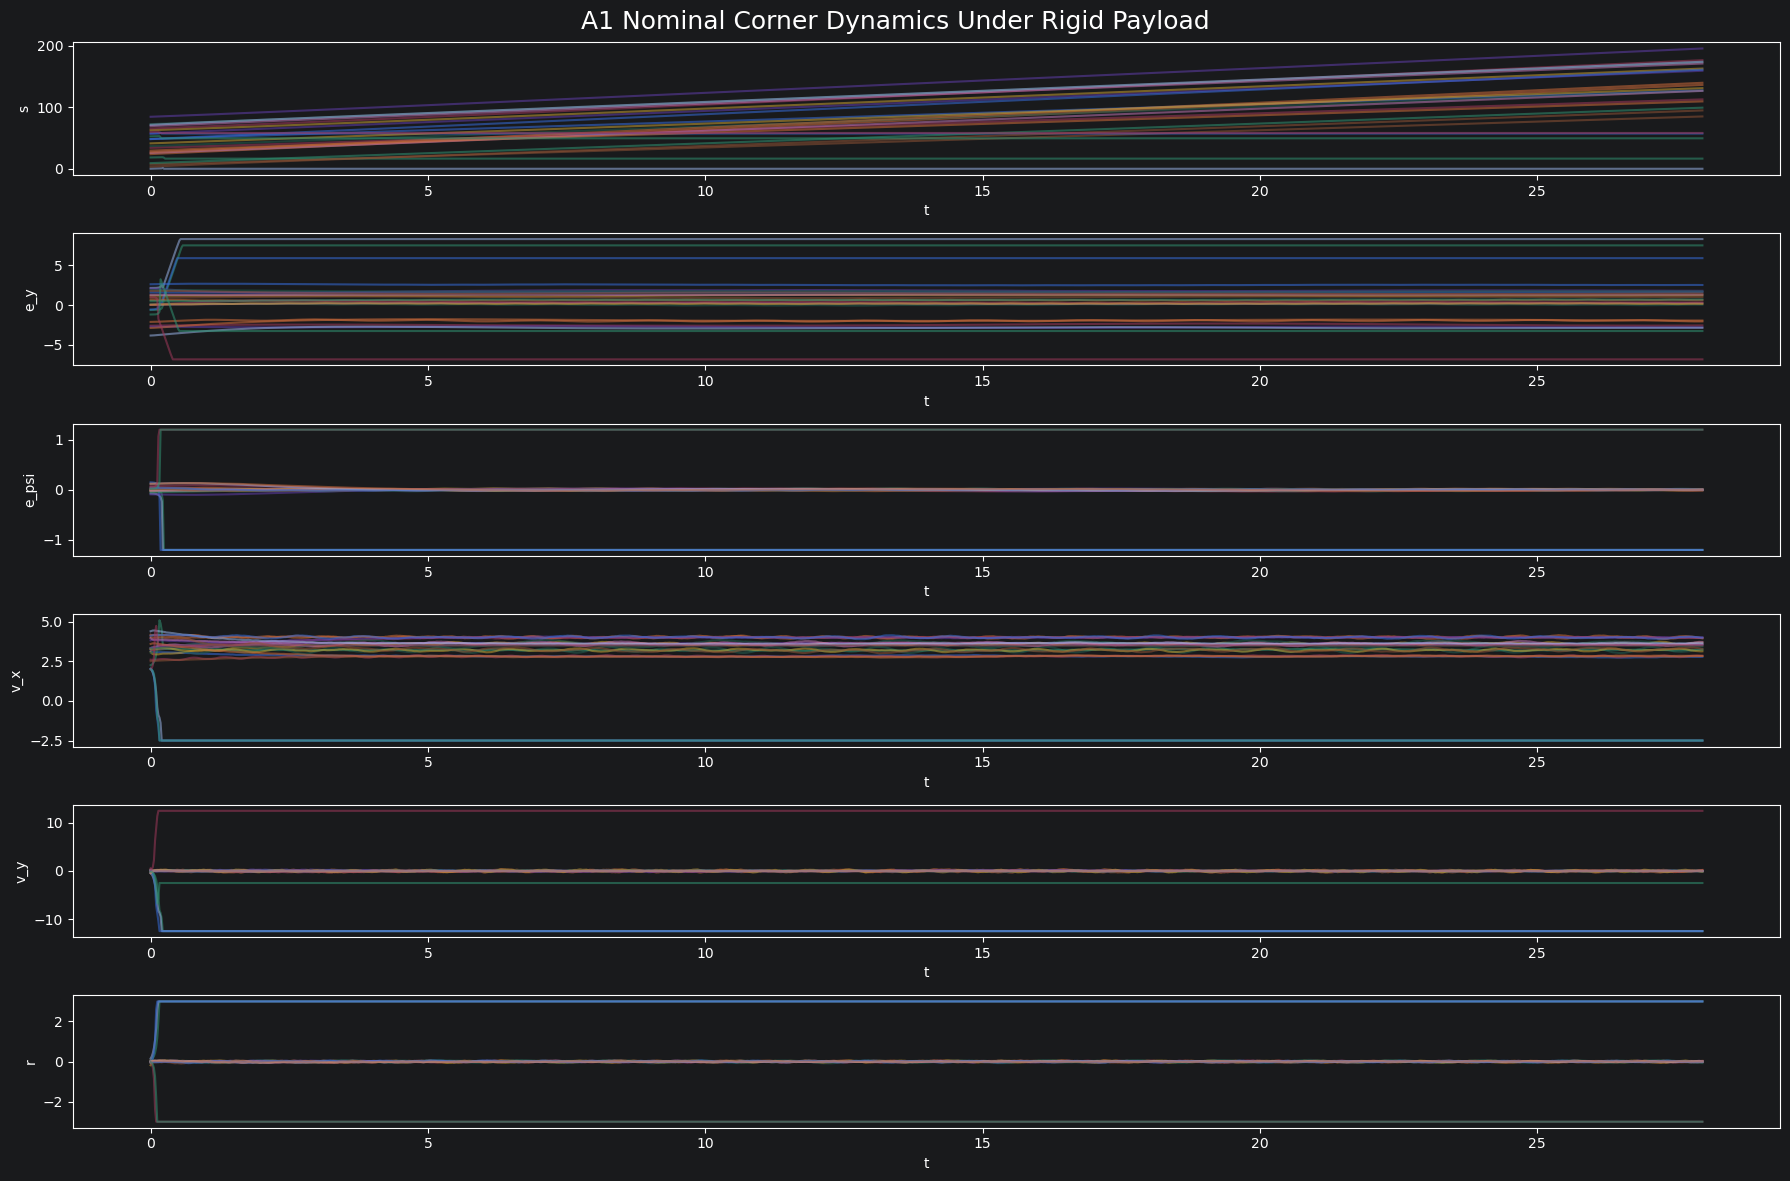

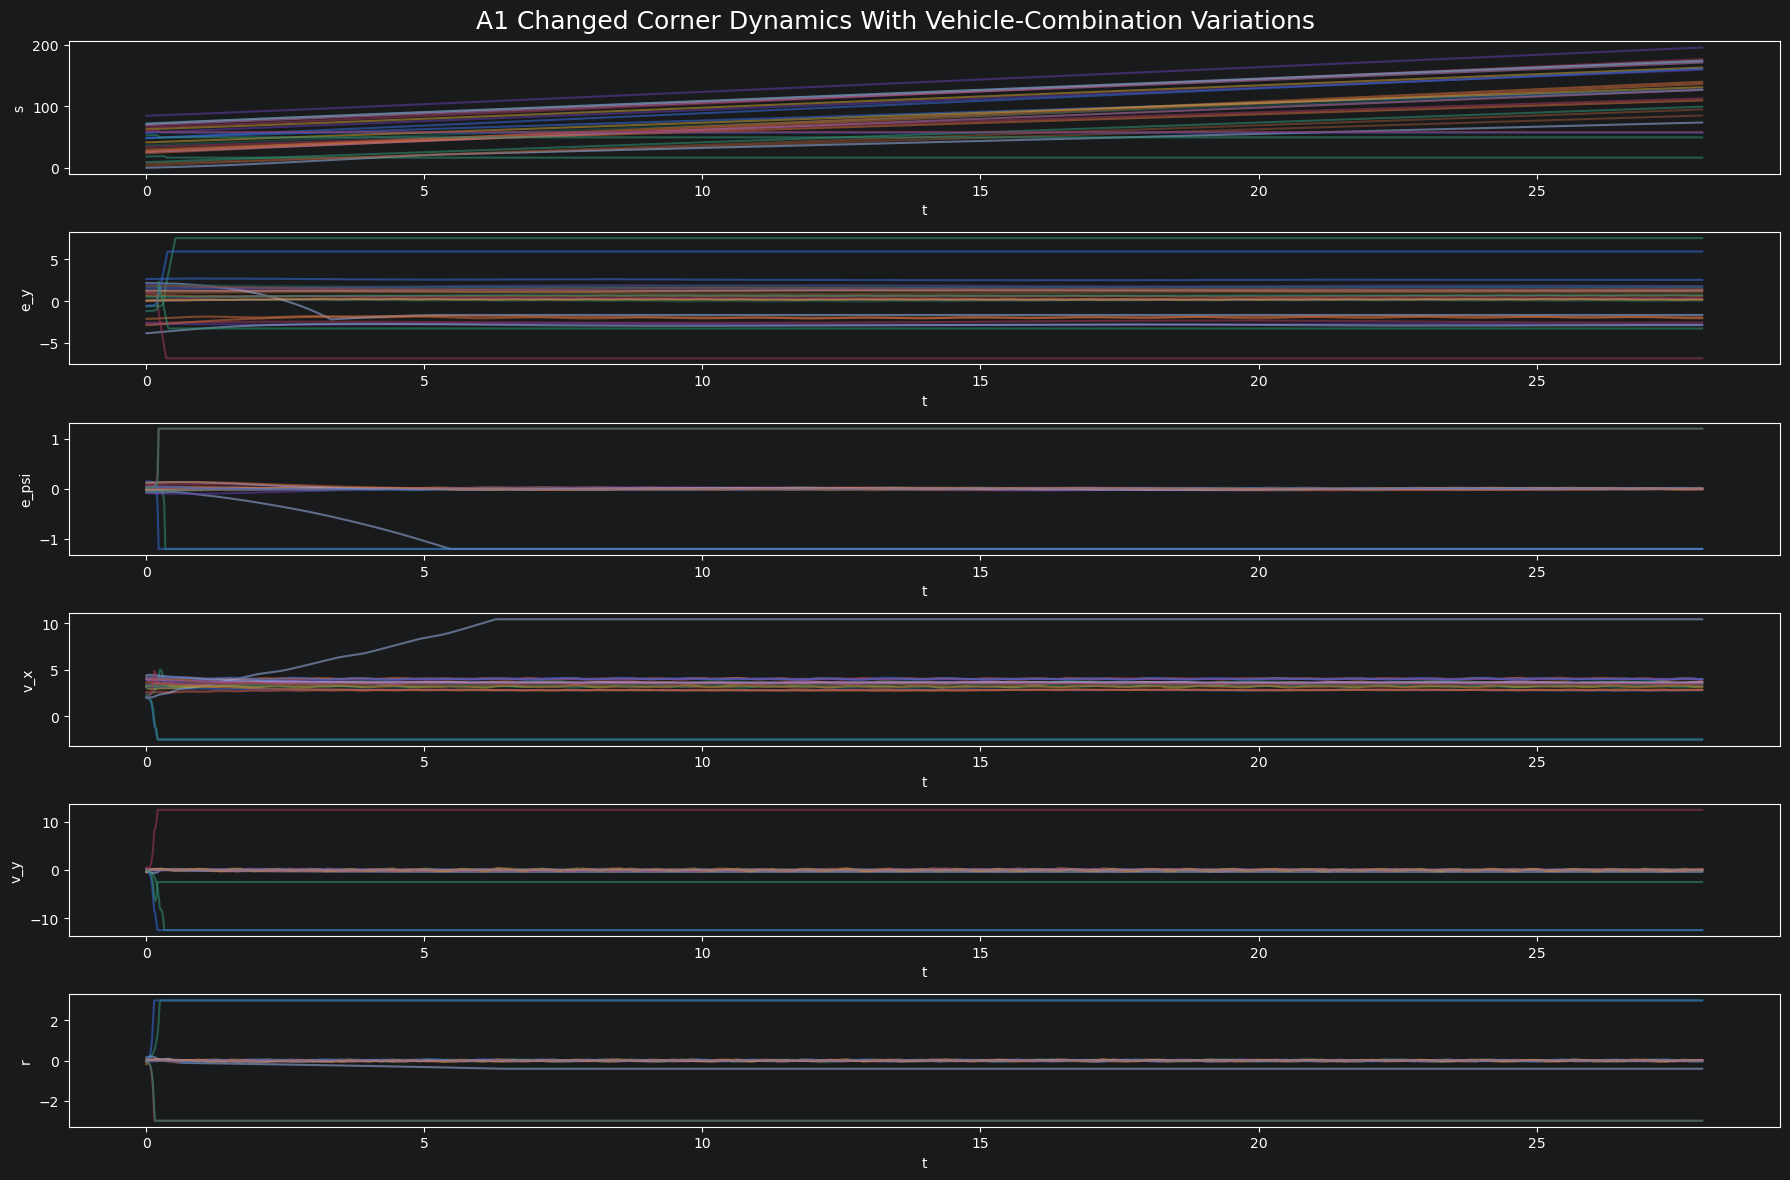

In [5]:
# =============================================================================
# System identification for A1 rigid payload transport
# =============================================================================
linear = True
a1_data = tf11_a1_runtime.generate_a1_dataset(
    run_cfg=RUN_CFG,
    koopman_cfg=KOOPMAN_CFG,
    set_global_seed_fn=set_global_seed,
    payload_module=payload_a1,
    single_vehicle_data_gen_multi_fn=single_vehicle_data_gen_multi,
    payload_cfg=A1_PAYLOAD_CFG,
    subset_weights=A1_VARIATION_SUBSET_WEIGHTS,
    dataset_tag=A1_DATASET_TAG,
)
A1_DATA = dict(a1_data)

X = A1_DATA["X"]
X_changed = A1_DATA["X_changed"]
U = A1_DATA["U"]
num_states = A1_DATA["num_states"]
num_inputs = A1_DATA["num_inputs"]
dt = A1_DATA["dt"]
sys_pars_base = A1_DATA["sys_pars_base"]
sys_pars_new_base = A1_DATA["sys_pars_new_base"]
sys_pars = A1_DATA["sys_pars"]
sys_pars_new = A1_DATA["sys_pars_new"]
sensor_noise = A1_DATA["sensor_noise"]
SNR_DB = A1_DATA["SNR_DB"]
train_path_length_target = A1_DATA["train_path_length_target"]
num_snaps = A1_DATA["num_snaps"]
num_traj = A1_DATA["num_traj"]
num_train = A1_DATA["num_train"]
num_val = A1_DATA["num_val"]
variation_labels_all = A1_DATA["variation_labels_all"]
variation_summary = A1_DATA["variation_summary"]
dataset_npz = A1_DATA["dataset_npz"]
dataset_pars = A1_DATA["dataset_pars"]

print("[A1] dataset assignment mode: explicit (no globals().update)")
print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)
print("Variation summary:", variation_summary)

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(min(num_traj, 24)):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.55)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("A1 Nominal Corner Dynamics Under Rigid Payload", fontsize=18)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(min(num_traj, 24)):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.55)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("A1 Changed Corner Dynamics With Vehicle-Combination Variations", fontsize=18)
plt.tight_layout()
plt.show()


Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim20_dt_0.02.pth
历史模型读取失败，跳过历史平滑: <built-in method __setstate__ of torch._C.Generator object at 0x0000015C862E55B0> returned a result with an exception set
✅ U_curr 与 X_curr 样本数匹配: 805248
✅ U_curr 与 X_curr 样本数匹配: 201312
Epoch [  10/140] | Train  total=1.9622e-04  pred=1.7852e-04  lifted=4.7815e-05| Val    total=2.0626e-04  pred=1.9354e-04  lifted=4.8132e-05
Epoch [  20/140] | Train  total=1.7705e-04  pred=1.7401e-04  lifted=4.7637e-05| Val    total=1.9371e-04  pred=1.9116e-04  lifted=4.6819e-05
Epoch [  30/140] | Train  total=1.7899e-04  pred=1.7521e-04  lifted=4.8226e-05| Val    total=1.9497e-04  pred=1.9144e-04  lifted=5.3067e-05
Epoch [  40/140] | Train  total=1.7817e-04  pred=1.7512e-04  lifted=4.3341e-05| Val    total=1.9404e-04  pred=1.9139e-04  lifted=4.5510e-05
Epoch [  50/140] | Train  total=1.7974e-04  pred=1.7492e-04  lifted=6.5118e-05| Val    total=1.9660e-04  pred=1.9110e-04  lifted=6.5312e-05
Epoch [  60/14

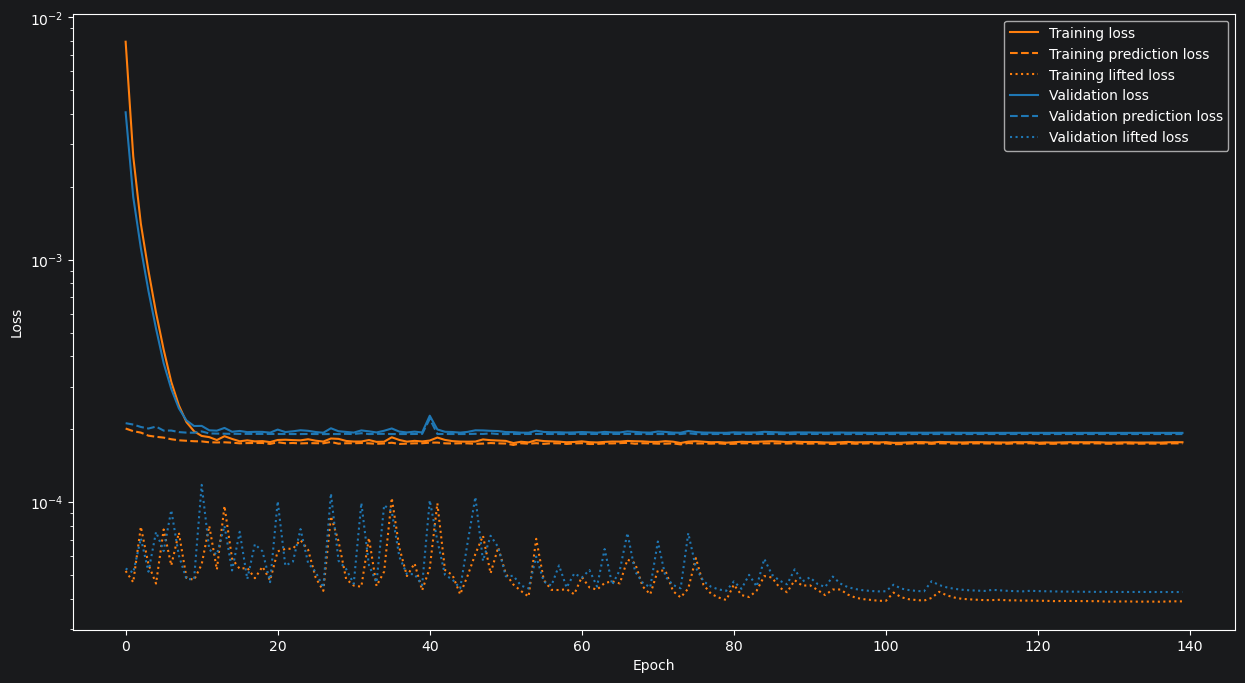

In [6]:
# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = KOOPMAN_CFG["encoder_hidden_width"]
net_params_lin["encoder_hidden_depth"] = KOOPMAN_CFG["encoder_hidden_depth"]
net_params_lin["encoder_output_dim"] = KOOPMAN_CFG["encoder_output_dim"]
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = KOOPMAN_CFG["lr"]
net_params_lin["epochs"] = KOOPMAN_CFG["epochs"]
net_params_lin["batch_size"] = KOOPMAN_CFG["batch_size"]

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 0.20
net_params_lin["lifted_loss_penalty"] = 0.05

net_params_lin["l2_reg"] = 1e-4
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt
net_params_lin["weight_decay"] = KOOPMAN_CFG["weight_decay"]

train = RUN_CFG["enable_koopman_training"]
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])
torch.cuda.empty_cache()

prev_A = prev_B = None
if RUN_CFG["enable_koopman_linear_refit"] and os.path.exists(file_koop_linear):
    try:
        prev_model = torch.load(file_koop_linear, map_location=DEVICE, weights_only=False)
        if not hasattr(prev_model, "A_lin") or not hasattr(prev_model, "B_lin"):
            prev_model.construct_koopman_model()
        prev_A = np.array(prev_model.A_lin, dtype=np.float32)
        prev_B = np.array(prev_model.B_lin, dtype=np.float32)
        print("检测到历史模型，将用于平滑本次线性矩阵。")
    except Exception as e:
        print("历史模型读取失败，跳过历史平滑:", e)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)

    # 强制对齐：x 和 u 的时间维以最小长度为准
    min_t_train = min(xs_train.shape[1], us_train.shape[1])
    xs_train = xs_train[:, :min_t_train, :]
    us_train = us_train[:, :min_t_train, :]

    min_t_val = min(xs_val.shape[1], us_val.shape[1])
    xs_val = xs_val[:, :min_t_val, :]
    us_val = us_val[:, :min_t_val, :]

    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )

    X_train, y_train = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_train, data_u=model_koop_dnn_lin.u_train
    )
    X_val, y_val = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_val, data_u=model_koop_dnn_lin.u_val, train_mode=False
    )

    from torch.utils.data import TensorDataset, DataLoader

    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).float()
    X_val_t = torch.from_numpy(X_val).float()
    y_val_t = torch.from_numpy(y_val).float()

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(RUN_CFG["seed"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
        persistent_workers=False,
        prefetch_factor=None,
        generator=loader_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model_koop_dnn_lin.train_loader = train_loader
    model_koop_dnn_lin.val_loader = val_loader

    model_koop_dnn_lin.model_pipeline(net_params_lin, print_epoch=True)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE, weights_only=False)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

# 始终构造一次线性 Koopman 矩阵（供 MPC 使用）
model_koop_dnn_lin.construct_koopman_model()

if RUN_CFG["enable_koopman_linear_refit"]:
    A_fit, B_fit, fit_info = fit_koopman_linear_matrices(
        model_koop_dnn_lin,
        xs_train,
        us_train,
        ridge_lambda=KOOPMAN_CFG["ridge_lambda"],
        batch_size=8192
    )

    A_refined = blend_matrix(model_koop_dnn_lin.A_lin.astype(np.float32), A_fit, KOOPMAN_CFG["linear_fit_blend"])
    B_refined = blend_matrix(model_koop_dnn_lin.B_lin.astype(np.float32), B_fit, KOOPMAN_CFG["linear_fit_blend"])

    if prev_A is not None and prev_B is not None:
        A_refined = blend_matrix(A_refined, prev_A, KOOPMAN_CFG["previous_model_blend"])
        B_refined = blend_matrix(B_refined, prev_B, KOOPMAN_CFG["previous_model_blend"])

    model_koop_dnn_lin.A_lin = A_refined
    model_koop_dnn_lin.B_lin = B_refined

    with torch.no_grad():
        model_koop_dnn_lin.net.A.weight.copy_(torch.from_numpy(A_refined).to(DEVICE))
        model_koop_dnn_lin.net.B.weight.copy_(torch.from_numpy(B_refined).to(DEVICE))

    print(f"线性重拟合完成: samples={fit_info['samples']}, lifted_rmse={fit_info['lifted_rmse']:.4e}")

if train:
    torch.save(model_koop_dnn_lin, file_koop_linear)

if len(model_koop_dnn_lin.train_loss_hist) > 0 and len(model_koop_dnn_lin.val_loss_hist) > 0:
    train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
    train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
    train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
    val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
    val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
    val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
    epochs = np.arange(0, len(train_loss))

    plt.figure(figsize=(15, 8))
    plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
    plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
    plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
    plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
    plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
    plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.show()
else:
    print("未执行本轮训练，跳过训练曲线绘制。")


open-loop eval vehicle idx: 0
x_unchanged_test shape: (4, 100, 6)
u_test shape: (4, 99, 2)
x_unchanged_eval shape: (1, 100, 6)
u_eval shape: (1, 99, 2)
A, B, C shapes: (27, 27) (27, 2) (6, 27)
stable spectral radius = 0.99900043
spectral radius = 1.003213
eigvals = [0.89944977+0.j         0.99659854+0.j         1.003213  +0.j
 1.0011098 +0.j         1.0000019 +0.00049529j 1.0000019 -0.00049529j
 1.0000579 +0.j         0.38297603+0.04315926j 0.38297603-0.04315926j
 0.3859586 +0.03431205j 0.3859586 -0.03431205j 0.39797518+0.02570021j
 0.39797518-0.02570021j 0.38114786+0.02644893j 0.38114786-0.02644893j
 0.38625097+0.01725224j 0.38625097-0.01725224j 0.3915998 +0.j
 0.37575623+0.01595685j 0.37575623-0.01595685j 0.38227805+0.01490449j
 0.38227805-0.01490449j 0.38262245+0.j         0.37700307+0.00250075j
 0.37700307-0.00250075j 0.37834325+0.01161553j 0.37834325-0.01161553j]


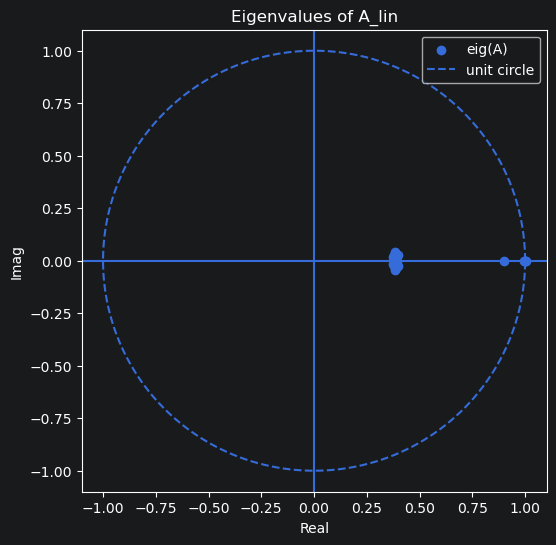

✅ U_curr 与 X_curr 样本数匹配: 99
✅ U_curr 与 X_curr 样本数匹配: 99
x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 0)
open-loop effective num_pred = 99


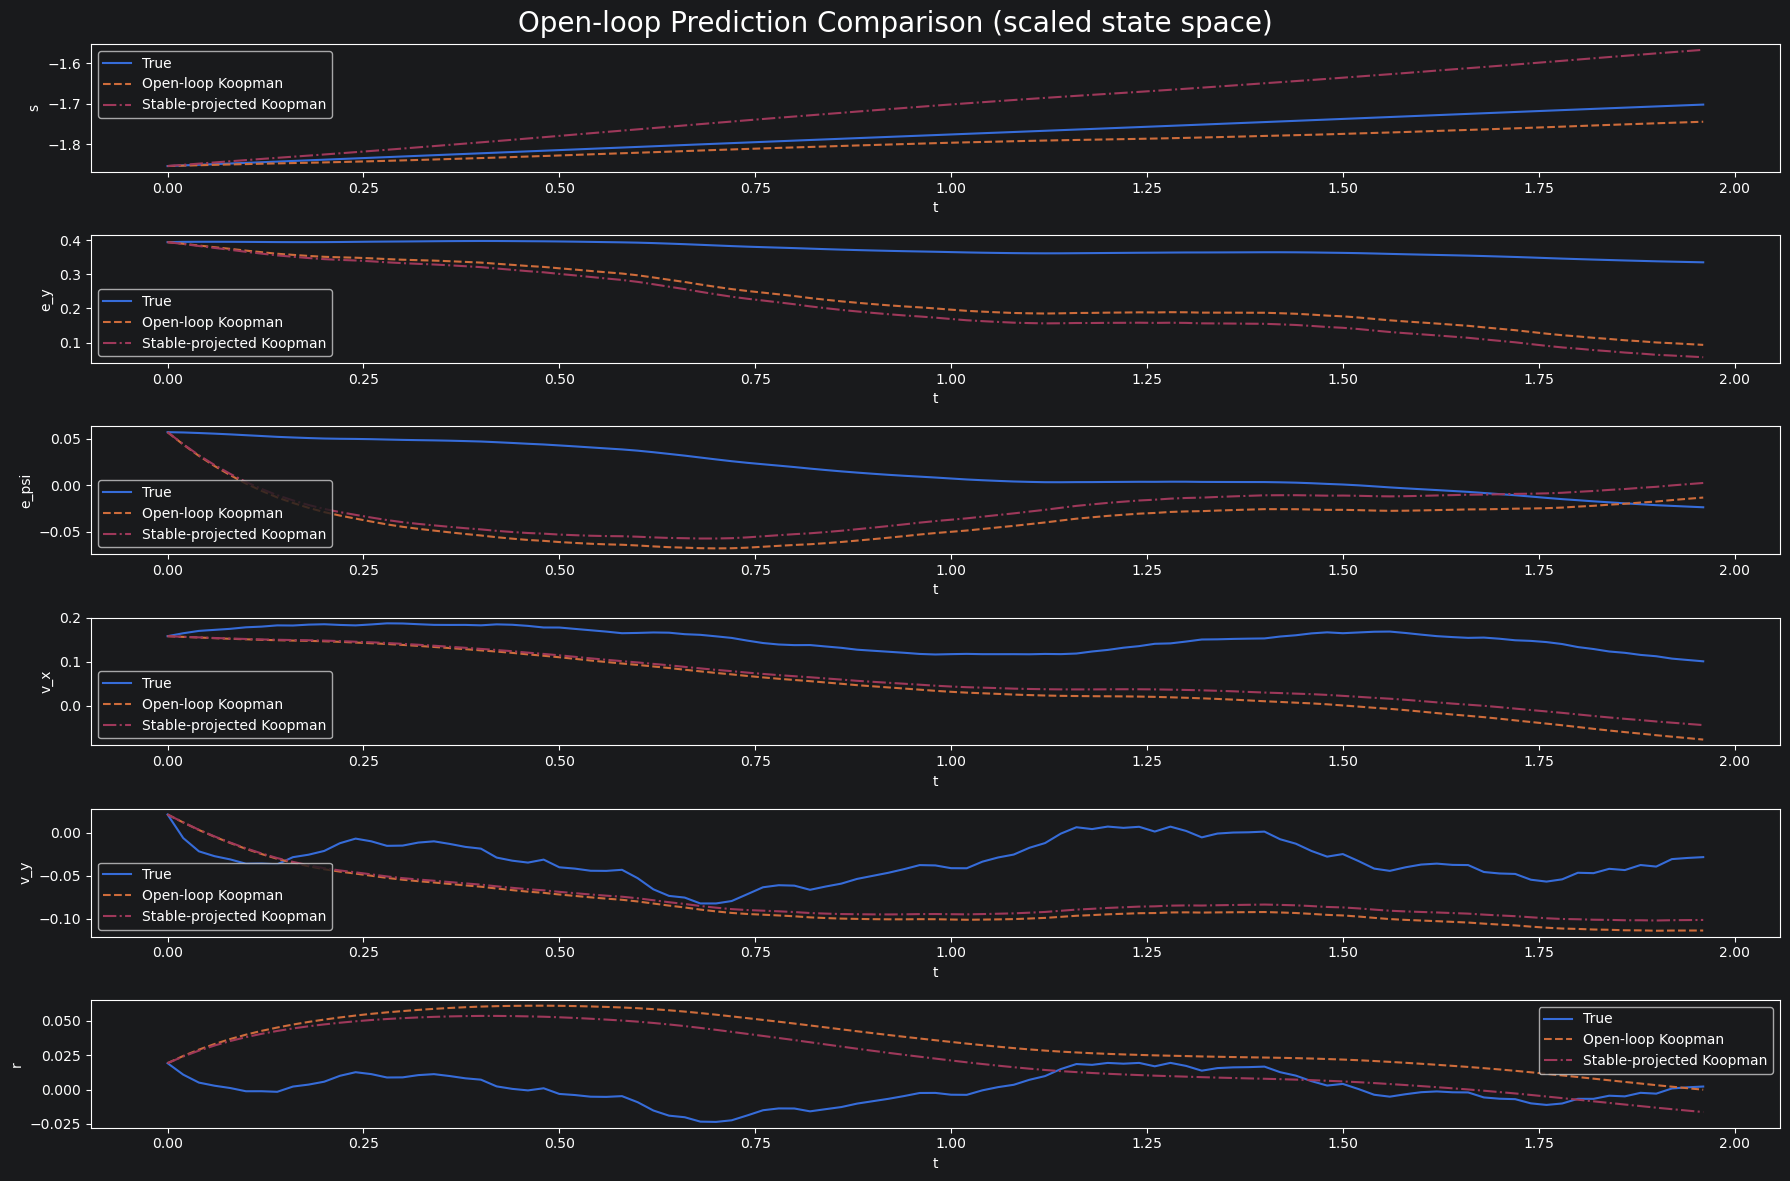

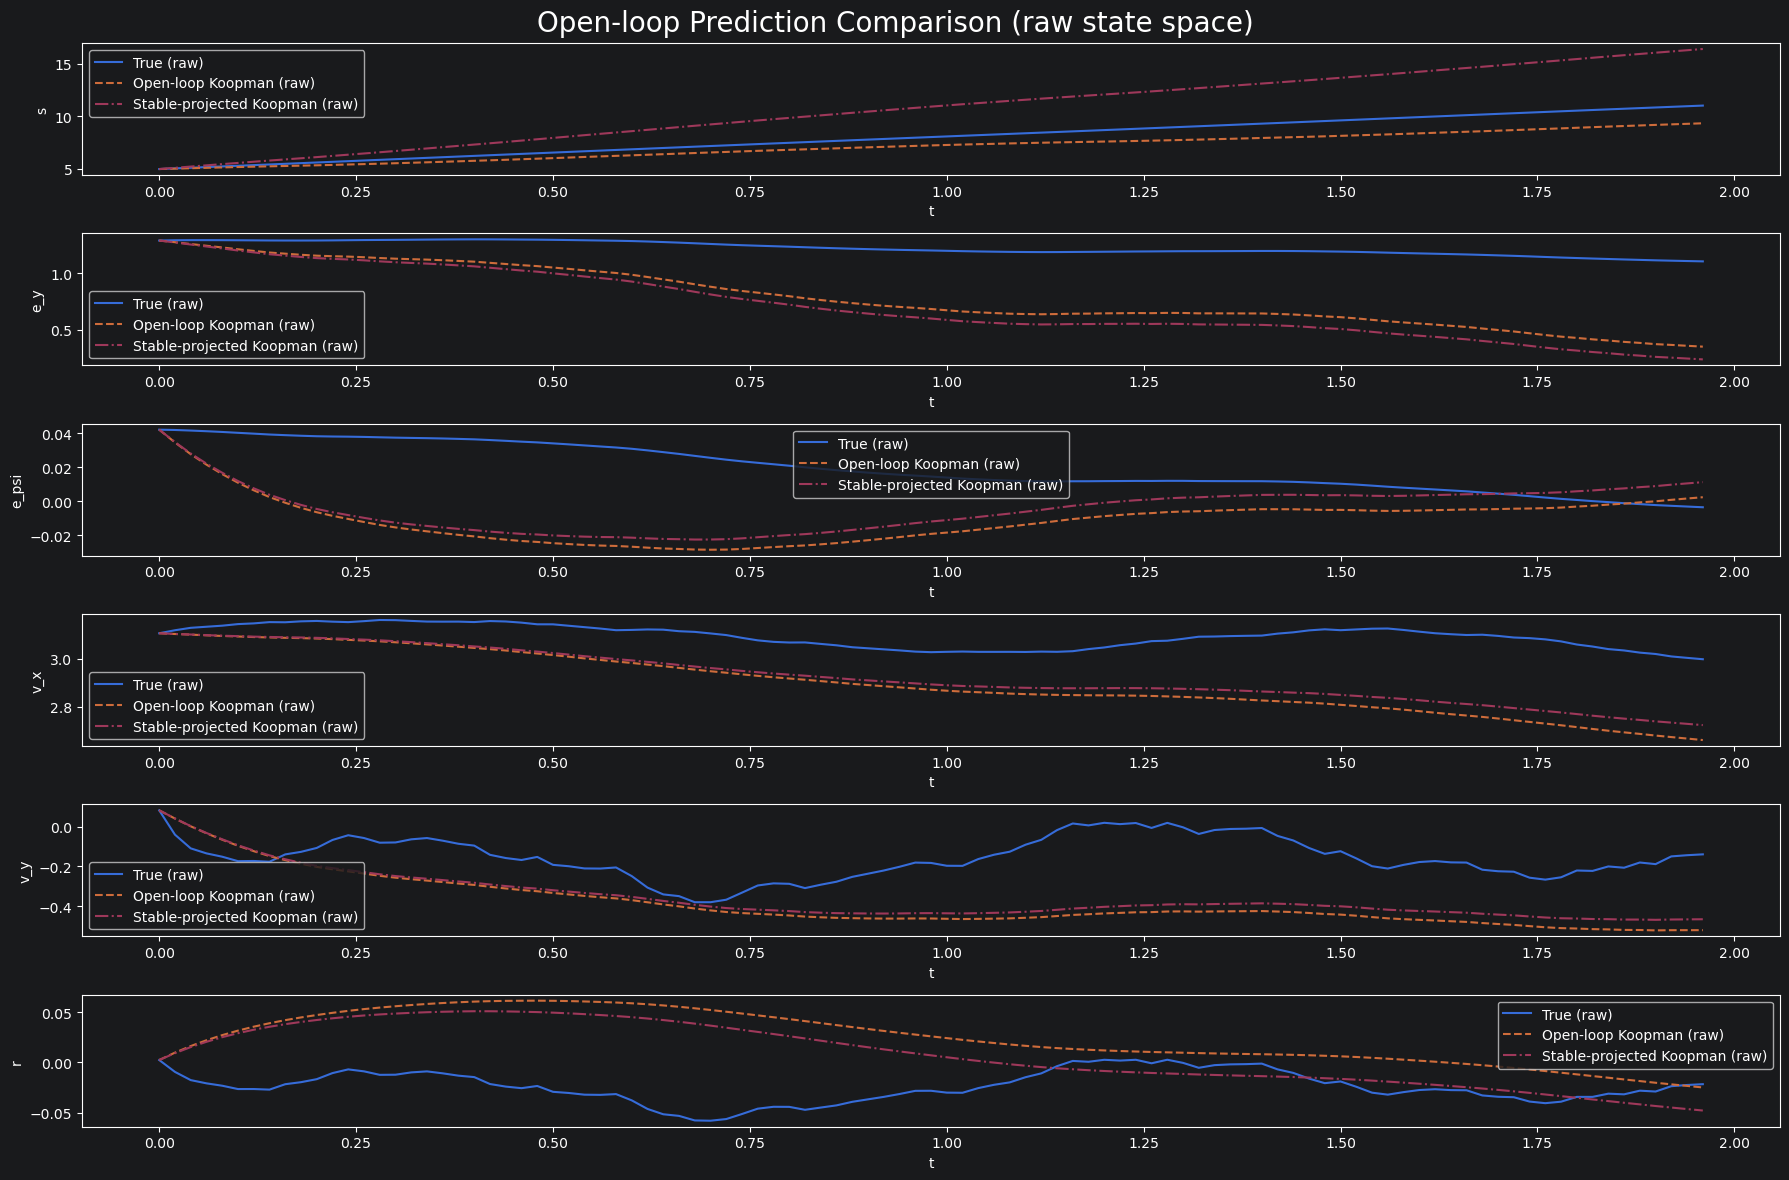

In [7]:
# =============================================================================
# Koopman Model Parameters (Open Loop Test)
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

# A1 数据生成器会返回四个角点车辆的轨迹，因此开环评估必须明确选定一辆车。
open_loop_vehicle_idx = 0
x_unchanged_eval = x_unchanged_test[open_loop_vehicle_idx:open_loop_vehicle_idx + 1, :, :]
x_changed_eval = x_changed_test[open_loop_vehicle_idx:open_loop_vehicle_idx + 1, :, :]
u_eval = u_test[open_loop_vehicle_idx:open_loop_vehicle_idx + 1, :, :]

print("open-loop eval vehicle idx:", open_loop_vehicle_idx)
print("x_unchanged_test shape:", x_unchanged_test.shape)
print("u_test shape:", u_test.shape)
print("x_unchanged_eval shape:", x_unchanged_eval.shape)
print("u_eval shape:", u_eval.shape)

# ====================== 正确提取 Koopman 矩阵 ======================
if not hasattr(model_koop_dnn_lin, 'A_lin'):
    print("尚未调用 construct_koopman_model()，现在自动调用...")
    model_koop_dnn_lin.construct_koopman_model()

A_lin = model_koop_dnn_lin.A_lin
B_lin = model_koop_dnn_lin.B_lin
C_lin = model_koop_dnn_lin.C_np

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

spectral_radius = np.max(np.abs(eigvals))
print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_eval, data_u=u_eval)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_eval, data_u=u_eval)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = min(x_unchanged_scaled.shape[0], u_scaled.shape[0], x_unchanged_eval.shape[1] - 1)
print("open-loop effective num_pred =", num_pred)

x_unchanged_scaled = x_unchanged_scaled[:num_pred, :]
u_scaled = u_scaled[:num_pred, :]
x_changed_scaled = x_changed_scaled[:num_pred, :]
if x_unchanged_prime_scaled.size > 0:
    x_unchanged_prime_scaled = x_unchanged_prime_scaled[:num_pred, :]
if x_changed_prime_scaled.size > 0:
    x_changed_prime_scaled = x_changed_prime_scaled[:num_pred, :]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_eval[0, :num_pred, :]

assert x_true_raw.shape[0] == num_pred
assert x_est_lin_raw.shape[0] == num_pred
assert x_est_lin_stable_raw.shape[0] == num_pred

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()


进行 one-step 预测 | 样本数: 99 | 状态维: 6


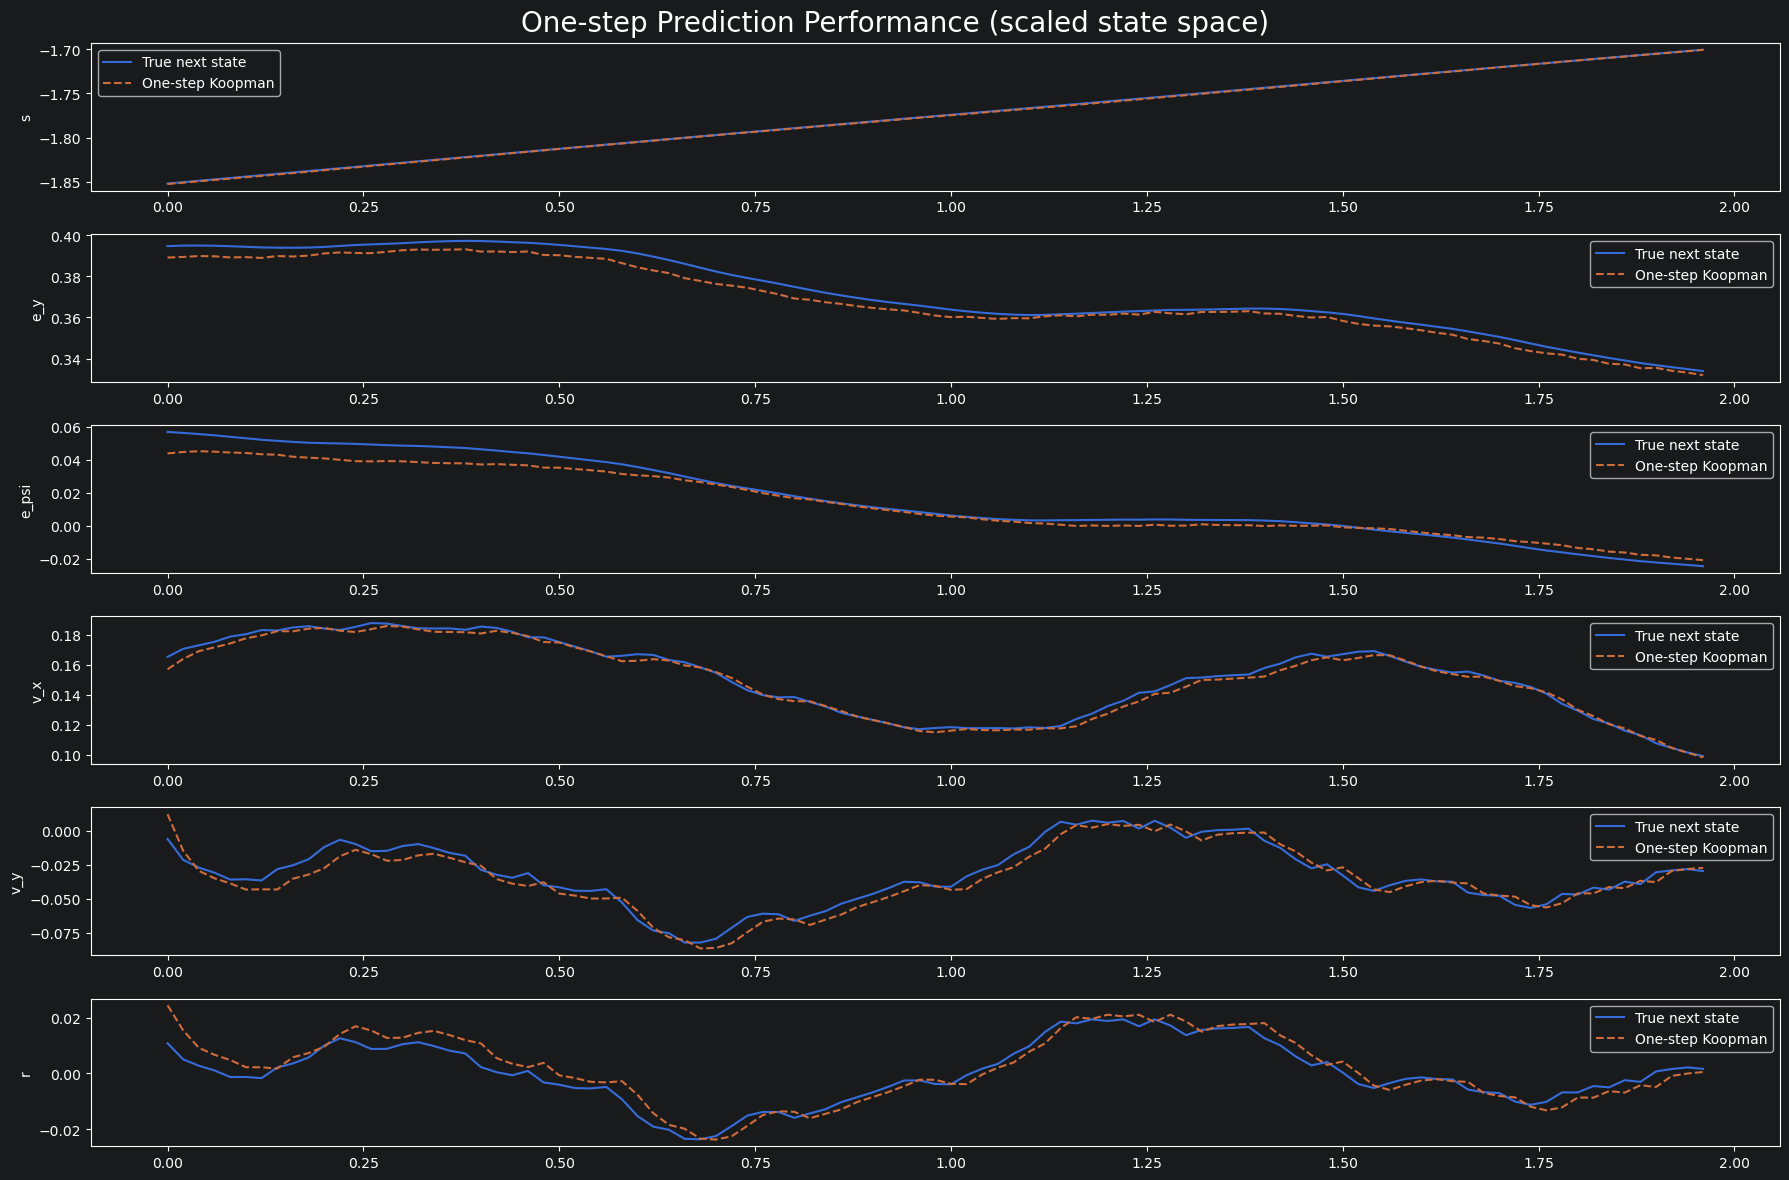

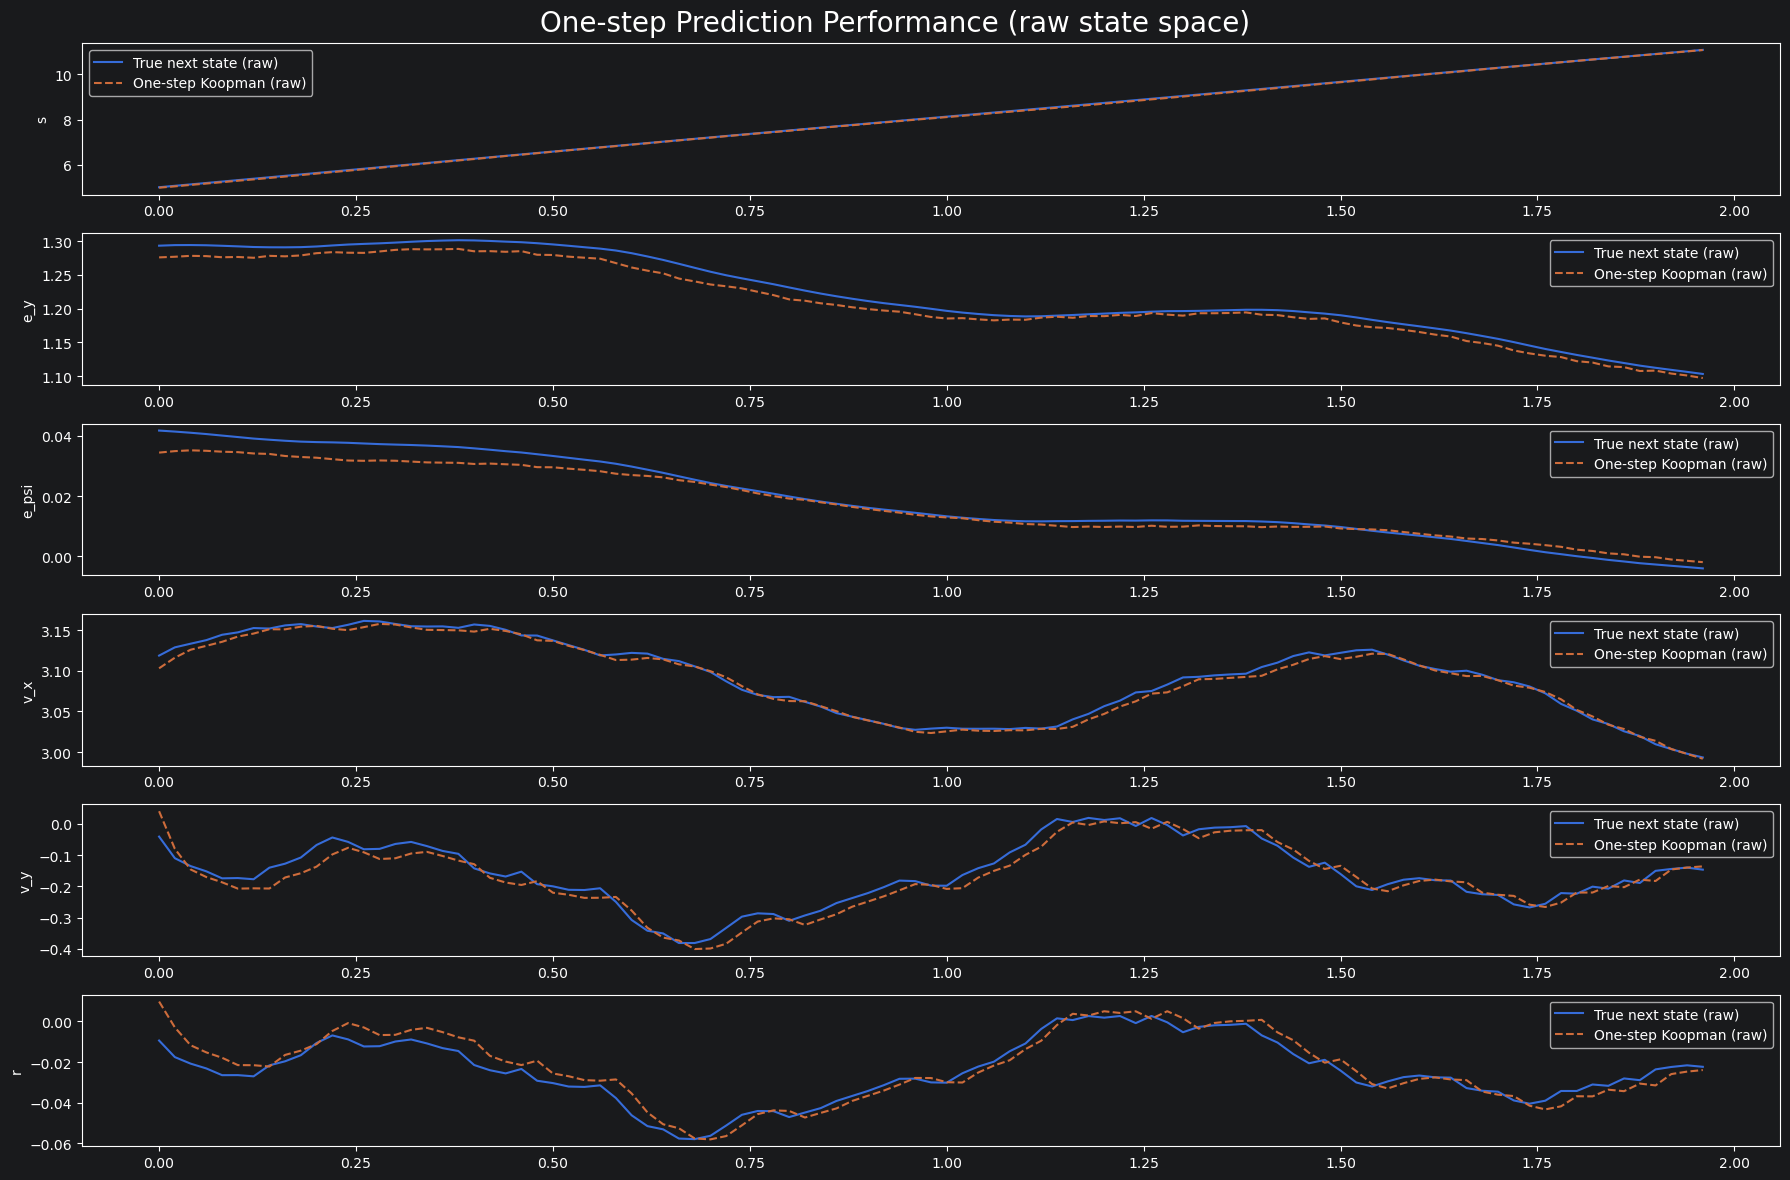

In [8]:
# ====================== One-step Prediction（按单车测试轨迹对齐） ======================
num_pred_1 = min(x_unchanged_scaled.shape[0], u_scaled.shape[0], x_unchanged_eval.shape[1] - 1)
x_true_next_raw = x_unchanged_eval[0, 1:1 + num_pred_1, :]
x_true_next_scaled = standardizer_x_kdnn.transform(x_true_next_raw)

x_one_step_pred = np.zeros((num_pred_1, num_states))

print(f"进行 one-step 预测 | 样本数: {num_pred_1} | 状态维: {num_states}")

for k in range(num_pred_1):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(num_pred_1) * dt

# ====================== 绘图（scaled） ======================
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_1, x_true_next_scaled[:, i], label="True next state")
    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

# ====================== 绘图（raw） ======================
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)

assert x_true_next_raw.shape[0] == num_pred_1
assert x_one_step_pred_raw.shape[0] == num_pred_1

T_plot_raw = np.arange(num_pred_1) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()


In [9]:
#
#=============================================================================
# Testing - TF11-A1 rigid payload transport baseline
# =============================================================================

# =========================
# Four vehicles at the rectangle corners
# =========================
num_vehicles = 4 if RUN_CFG["enable_four_vehicle"] else 1
vx_nom = 3.0
x0_payload_center, formation_offsets, x0_vehicles = tf11_a1_runtime.build_a1_initial_states(payload_a1, A1_PAYLOAD_CFG, vx_nom)

# =========================
# Reference path generation
# =========================
path_length = MPC_CFG["path_length"]
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

if RUN_CFG["enable_curved_tracking"]:
    A1 = 1.15
    A2 = -1.15
    x1 = 0.30 * path_length
    x2 = 0.72 * path_length
    sigma1 = 0.10 * path_length
    sigma2 = 0.10 * path_length
    y_ref_dlc = A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2) + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
    y_ref_wave = 0.09 * np.sin(2.0 * np.pi * 2.2 * x_path / path_length) * np.exp(-((x_path - 0.5 * path_length) / (0.45 * path_length)) ** 2)
    y_ref_path = y_ref_dlc + y_ref_wave
else:
    y_ref_path = np.zeros_like(x_path)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(x_path, y_ref_path)
kappa_abs = np.abs(curvature_ref_path)
vx_ref_profile = vx_nom / (1.0 + MPC_CFG["speed_profile_curv_gain"] * kappa_abs)
vx_ref_profile = np.clip(vx_ref_profile, MPC_CFG["speed_profile_min"], vx_nom)

smooth_beta = float(np.clip(MPC_CFG["speed_profile_smooth"], 0.0, 0.98))
for ii in range(1, vx_ref_profile.size):
    vx_ref_profile[ii] = smooth_beta * vx_ref_profile[ii - 1] + (1.0 - smooth_beta) * vx_ref_profile[ii]

slow_start = float(MPC_CFG["terminal_slowdown_start_s"])
slow_floor = float(np.clip(MPC_CFG["terminal_slowdown_floor"], 0.4, 1.0))
if s_ref_path[-1] > slow_start:
    slow_ratio = np.clip((s_ref_path - slow_start) / max(s_ref_path[-1] - slow_start, 1e-6), 0.0, 1.0)
    terminal_scale = 1.0 - (1.0 - slow_floor) * slow_ratio
    vx_ref_profile = np.clip(vx_ref_profile * terminal_scale, MPC_CFG["speed_profile_min"] * 0.9, vx_nom)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_ref_profile
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_ref_profile * curvature_ref_path
x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T


In [10]:
# =========================
# Solver settings（防卡死调优 + 可开关）
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = True
solver_settings["polish_refine_iter"] = 3
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 10
solver_settings["max_iter"] = 6000
solver_settings["eps_abs"] = 8e-4
solver_settings["eps_rel"] = 8e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3
solver_settings["sqp_step_size"] = 0.85
solver_settings["du_clip"] = 0.45
solver_settings["retry_on_fail"] = 1
solver_settings["retry_relax_factor"] = 1.8
solver_settings["accept_solved_inaccurate"] = True
solver_settings["accept_partial_solution"] = True
solver_settings["accept_partial_prim_res"] = 4e-3
solver_settings["accept_partial_dual_res"] = 4e-3
solver_settings["verbose"] = False

if RUN_CFG["enable_solver_guard"]:
    solver_settings["time_limit"] = MPC_CFG["osqp_time_limit"]

# 初始化参考轨迹列表
x_ref_mpc_vehicles = []


In [11]:
# =========================
# MPC horizon / ref preview + A1 rigid-payload reference bundle
# =========================
N_lin_noadapt = MPC_CFG["horizon"]
max_iter_lin = MPC_CFG["max_sqp_iters"]

A1_COORDINATOR = None
A1_REF_BUNDLE = None
A1_COORDINATOR, A1_REF_BUNDLE = tf11_a1_runtime.build_a1_reference_bundle(
    payload_module=payload_a1,
    payload_cfg=A1_PAYLOAD_CFG,
    standardizer_x=standardizer_x_kdnn,
    x_ref_raw=x_ref_raw,
    leader_idx=FORMATION_CFG["leader_index"],
    horizon_pad=N_lin_noadapt + 2,
)
A1_REFERENCE_VERSION = A1_NOTEBOOK_VERSION

x_ref_raw_vehicles = A1_REF_BUNDLE["raw_vehicle_refs"]
a1_ref_vehicle_histories = A1_REF_BUNDLE["corner_ref_histories"]
x_ref_mpc_vehicles = A1_REF_BUNDLE["mpc_vehicle_refs"]

print("[A1] rigid reference bundle ready")
print("[A1] reference version:", A1_REFERENCE_VERSION)
print("[A1] ref_team_hist shape:", A1_REF_BUNDLE["team_ref_hist"].shape)
print("[A1] ref_vehicle_histories[0] shape:", a1_ref_vehicle_histories[0].shape)
print("[A1] x_ref_mpc_vehicles[0] shape:", x_ref_mpc_vehicles[0].shape)

# =========================
# Relaxed raw bounds -> scaled bounds
# =========================
xmin_raw = np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0])
xmax_raw = np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0])

xmin_lin_noadapt = standardizer_x_kdnn.transform(xmin_raw.reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(xmax_raw.reshape(1, -1)).flatten()

umax_lin_noadapt = np.array([MPC_CFG["steer_limit"], MPC_CFG["accel_limit"]], dtype=float)
umin_lin_noadapt = -umax_lin_noadapt

# ====================== 基础权重 ======================
Q_base_lin = scipy.sparse.diags([
    0.0,
    3500.0,
    1200.0,
    8.0,
    1.0,
    1.0
])

QN_base_lin = scipy.sparse.diags([
    0.0,
    5000.0,
    2000.0,
    12.0,
    1.0,
    1.0
])

R_mpc_lin_noadapt = scipy.sparse.diags([120.0, 12.0])



from control_files.tf11_a1.core_utils import (
    spectral_project_matrix,
    configure_raw_linear_fit_context,
    fit_raw_linear_model_scaled,
)

configure_raw_linear_fit_context(
    num_states=num_states,
    num_inputs=num_inputs,
    standardizer_x=standardizer_x_kdnn,
    standardizer_u=standardizer_u_kdnn,
)

# 无 Koopman 对照模型（直接在 scaled 原状态空间拟合线性模型）
A_raw_scaled, B_raw_scaled = fit_raw_linear_model_scaled(xs_train, us_train, ridge_lambda=8e-5)
A_raw_scaled_stable = spectral_project_matrix(A_raw_scaled, radius=0.998)
C_raw_scaled = np.eye(num_states)

print("[对照模型] A_raw_scaled shape:", A_raw_scaled.shape, "| B_raw_scaled shape:", B_raw_scaled.shape)
print("[对照模型] spectral radius (stable proj):", np.max(np.abs(np.linalg.eigvals(A_raw_scaled_stable))))


[A1] rigid reference bundle ready
[A1] reference version: tf11_a1_stable_2026_04_17
[A1] ref_team_hist shape: (1001, 6)
[A1] ref_vehicle_histories[0] shape: (1001, 6)
[A1] x_ref_mpc_vehicles[0] shape: (6, 1035)
[对照模型] A_raw_scaled shape: (6, 6) | B_raw_scaled shape: (6, 2)
[对照模型] spectral radius (stable proj): 0.99800014


In [12]:

# =========================
# TF11-A1 控制/自适应 helper 绑定（模块化）
# =========================
leader_idx = FORMATION_CFG["leader_index"]
formation_targets = []
for v in range(num_vehicles):
    formation_targets.append({
        "ds": float(x0_vehicles[v][0] - x0_vehicles[leader_idx][0]),
        "dey": float(x0_vehicles[v][1] - x0_vehicles[leader_idx][1])
    })

import importlib
import control_files.tf11_a1.mpc_helpers as tf11_a1_mpc_helpers

tf11_a1_mpc_helpers = importlib.reload(tf11_a1_mpc_helpers)
tf11_a1_mpc_helpers.bind_context(
    MPC_CFG=MPC_CFG,
    PPC_CFG=PPC_CFG,
    FORMATION_CFG=FORMATION_CFG,
    KOOPMAN_CFG=KOOPMAN_CFG,
    A_lin=A_lin,
    A_lin_stable=A_lin_stable,
    B_lin=B_lin,
    C_lin=C_lin,
    model_koop_dnn_lin=model_koop_dnn_lin,
    xs_train=xs_train,
    us_train=us_train,
    spectral_project_matrix=spectral_project_matrix,
    num_states=num_states,
    AdaptNet_linear=AdaptNet_linear,
)

adaptive_mpc_weights = tf11_a1_mpc_helpers.adaptive_mpc_weights
maybe_update_ppc = tf11_a1_mpc_helpers.maybe_update_ppc
coop_gain_scale_by_s = tf11_a1_mpc_helpers.coop_gain_scale_by_s
apply_coop_correction = tf11_a1_mpc_helpers.apply_coop_correction
apply_emergency_guard = tf11_a1_mpc_helpers.apply_emergency_guard
enforce_progress_and_stability = tf11_a1_mpc_helpers.enforce_progress_and_stability

should_take_adapt_sample = tf11_a1_mpc_helpers.should_take_adapt_sample
clip_fro_norm = tf11_a1_mpc_helpers.clip_fro_norm
fit_koopman_bilinear_matrices = tf11_a1_mpc_helpers.fit_koopman_bilinear_matrices
get_tf9_model_pack = tf11_a1_mpc_helpers.get_tf9_model_pack
resolve_adapt_mode = tf11_a1_mpc_helpers.resolve_adapt_mode
weighted_stack = tf11_a1_mpc_helpers.weighted_stack

fit_delta_linear_ridge = tf11_a1_mpc_helpers.fit_delta_linear_ridge
fit_delta_linear_net = tf11_a1_mpc_helpers.fit_delta_linear_net
fit_delta_bilinear_ridge = tf11_a1_mpc_helpers.fit_delta_bilinear_ridge
apply_online_delta = tf11_a1_mpc_helpers.apply_online_delta

# 仅保留兼容名；A1 主流程使用 tf11_a1_runtime.run_tf11_a1_main
run_tf9_main = tf11_a1_mpc_helpers.run_tf9_main_placeholder

print("[A1] 控制/自适应 helper 已模块化导入: control_files/tf11_a1/mpc_helpers.py")


[A1] 控制/自适应 helper 已模块化导入: control_files/tf11_a1/mpc_helpers.py


In [13]:

# =========================
# TF11-A1 指标函数与状态判定（模块化）
# =========================
import importlib
import control_files.tf11_a1.metrics_utils as tf11_a1_metrics

tf11_a1_metrics = importlib.reload(tf11_a1_metrics)

_is_solver_success_status = tf11_a1_metrics.is_solver_success_status
_solver_success_rate = tf11_a1_metrics.solver_success_rate
_full_path_rate = tf11_a1_metrics.full_path_rate
_build_case_metrics = lambda result: tf11_a1_metrics.build_case_metrics(result, num_vehicles=num_vehicles)


In [14]:

# =========================
# TF11-A1 case runner helper（模块化）
# =========================
import importlib
import control_files.tf11_a1.case_runner_utils as tf11_a1_case_runner

tf11_a1_case_runner = importlib.reload(tf11_a1_case_runner)

run_tf10_case = tf11_a1_case_runner.make_run_tf10_case(
    tf10_modules_default=TF10_MODULES_DEFAULT,
    run_cfg=RUN_CFG,
    method_cfg=METHOD_CFG,
    mpc_cfg=MPC_CFG,
    solver_settings=solver_settings,
    run_case_fn=run_tf9_main,
    build_case_metrics_fn=_build_case_metrics,
    namespace=globals(),
)

print_tf10_case_summary = tf11_a1_case_runner.print_tf10_case_summary


In [15]:

# =========================
# TF11-A1 explicit runtime context（模块化）
# =========================
from control_files.tf11_a1.context_utils import build_a1_runtime_context_from_globals

A1_RUNTIME_KEYS = ['ADAPT_CFG', 'METHOD_CFG', 'MPC_CFG', 'N_lin_noadapt', 'NonlinearMPCController', 'PPC_CFG', 'QN_base_lin', 'Q_base_lin', 'RUN_CFG', 'R_mpc_lin_noadapt', 'SNR_DB', 'TF11_MODULES_MAIN', '_build_case_metrics', 'adaptive_mpc_weights', 'apply_coop_correction', 'apply_emergency_guard', 'apply_online_delta', 'clip_closed_loop_state', 'curvature_ref_path', 'dt', 'enforce_progress_and_stability', 'fit_delta_bilinear_ridge', 'fit_delta_linear_net', 'fit_delta_linear_ridge', 'get_tf9_model_pack', 'is_finite_vector', 'leader_idx', 'lift_scaled', 'max_iter_lin', 'maybe_update_ppc', 'model_koop_dnn_lin', 'net_params_lin', 'num_inputs', 'num_states', 'num_vehicles', 'resolve_adapt_mode', 's_ref_path', 'safe_FK_step', 'scale_state', 'should_take_adapt_sample', 'solver_settings', 'standardizer_x_kdnn', 'sys_pars', 'sys_pars_new', 'traj_length', 'umax_lin_noadapt', 'umin_lin_noadapt', 'vx_nom', 'weighted_stack', 'x0_vehicles', 'x_ref_raw', 'xmax_lin_noadapt', 'xmin_lin_noadapt']

build_a1_runtime_context = lambda: build_a1_runtime_context_from_globals(
    runtime_keys=A1_RUNTIME_KEYS,
    global_ns=globals(),
    coordinator=A1_COORDINATOR,
    ref_bundle=A1_REF_BUNDLE,
    notebook_version=A1_NOTEBOOK_VERSION,
)

print("[A1] explicit runtime context helper ready. key_count =", len(A1_RUNTIME_KEYS))


[A1] explicit runtime context helper ready. key_count = 53


In [16]:

# =========================
# TF11-A1 main method: rigid payload + bilinear adaptive Koopman
# （在线自适应更新调试打印：X/Y 形状 + ||ΔA||, ||ΔB||）
# =========================
payload_a1 = importlib.reload(payload_a1)
tf11_a1_runtime = importlib.reload(tf11_a1_runtime)

A1_COORDINATOR, A1_REF_BUNDLE = tf11_a1_runtime.build_a1_reference_bundle(
    payload_module=payload_a1,
    payload_cfg=A1_PAYLOAD_CFG,
    standardizer_x=standardizer_x_kdnn,
    x_ref_raw=x_ref_raw,
    leader_idx=FORMATION_CFG["leader_index"],
    horizon_pad=N_lin_noadapt + 2,
)
A1_REFERENCE_VERSION = A1_NOTEBOOK_VERSION
x_ref_raw_vehicles = A1_REF_BUNDLE["raw_vehicle_refs"]
a1_ref_vehicle_histories = A1_REF_BUNDLE["corner_ref_histories"]
x_ref_mpc_vehicles = A1_REF_BUNDLE["mpc_vehicle_refs"]
A1_RUNTIME_CTX = build_a1_runtime_context()

# -------------------------
# 在线自适应更新调试包装（只在主程序 cell 生效）
# -------------------------
_adapt_dbg_state = {
    "idx": 0,
    "mode": None,
    "x_shape": None,
    "y_shape": None,
}

_orig_fit_linear_net = A1_RUNTIME_CTX["fit_delta_linear_net"]
_orig_fit_linear_ridge = A1_RUNTIME_CTX["fit_delta_linear_ridge"]
_orig_fit_bilinear_ridge = A1_RUNTIME_CTX["fit_delta_bilinear_ridge"]
_orig_apply_online_delta = A1_RUNTIME_CTX["apply_online_delta"]


def _dbg_fit_linear_net(Z_hist, U_hist, dZ_hist, adapt_cfg, nz, nu, net_params, del_A_prev=None, del_B_prev=None):
    X_dbg = np.hstack([Z_hist, U_hist])
    Y_dbg = dZ_hist
    _adapt_dbg_state["mode"] = "linear_net"
    _adapt_dbg_state["x_shape"] = tuple(X_dbg.shape)
    _adapt_dbg_state["y_shape"] = tuple(Y_dbg.shape)
    return _orig_fit_linear_net(Z_hist, U_hist, dZ_hist, adapt_cfg, nz, nu, net_params, del_A_prev=del_A_prev, del_B_prev=del_B_prev)


def _dbg_fit_linear_ridge(Z_hist, U_hist, dZ_hist, W, ridge_lambda=1e-4):
    X_dbg = np.hstack([Z_hist, U_hist])
    Y_dbg = dZ_hist
    _adapt_dbg_state["mode"] = "linear_ridge"
    _adapt_dbg_state["x_shape"] = tuple(X_dbg.shape)
    _adapt_dbg_state["y_shape"] = tuple(Y_dbg.shape)
    return _orig_fit_linear_ridge(Z_hist, U_hist, dZ_hist, W, ridge_lambda=ridge_lambda)


def _dbg_fit_bilinear_ridge(Z_hist, U_hist, dZ_hist, W, ridge_lambda=1e-4):
    ZU = np.array([np.kron(Z_hist[i], U_hist[i]) for i in range(Z_hist.shape[0])], dtype=np.float64)
    X_dbg = np.hstack([Z_hist, ZU])
    Y_dbg = dZ_hist
    _adapt_dbg_state["mode"] = "bilinear_ridge"
    _adapt_dbg_state["x_shape"] = tuple(X_dbg.shape)
    _adapt_dbg_state["y_shape"] = tuple(Y_dbg.shape)
    return _orig_fit_bilinear_ridge(Z_hist, U_hist, dZ_hist, W, ridge_lambda=ridge_lambda)


def _dbg_apply_online_delta(dynamics_obj, dA, dB, structure_name, adapt_cfg):
    _adapt_dbg_state["idx"] += 1
    raw_da = float(np.linalg.norm(dA))
    raw_db = float(np.linalg.norm(dB))
    da_norm, db_norm = _orig_apply_online_delta(dynamics_obj, dA, dB, structure_name, adapt_cfg)

    print(
        f"[ADAPT-UPDATE {_adapt_dbg_state['idx']:03d}] "
        f"mode={_adapt_dbg_state.get('mode', 'unknown')} | "
        f"X={_adapt_dbg_state.get('x_shape')} | Y={_adapt_dbg_state.get('y_shape')} | "
        f"||ΔA||={raw_da:.4e} (applied {da_norm:.4e}) | "
        f"||ΔB||={raw_db:.4e} (applied {db_norm:.4e})"
    )
    return da_norm, db_norm


A1_RUNTIME_CTX["fit_delta_linear_net"] = _dbg_fit_linear_net
A1_RUNTIME_CTX["fit_delta_linear_ridge"] = _dbg_fit_linear_ridge
A1_RUNTIME_CTX["fit_delta_bilinear_ridge"] = _dbg_fit_bilinear_ridge
A1_RUNTIME_CTX["apply_online_delta"] = _dbg_apply_online_delta

print()
print("=" * 90)
print("TF11-A1 main method: rigid rectangular payload + bilinear adaptive Koopman")
print("=" * 90)
print("[A1] notebook version:", A1_NOTEBOOK_VERSION)
print("[A1] reference version:", A1_REFERENCE_VERSION)
print("[A1] runtime context keys:", len(A1_RUNTIME_CTX))
print("[A1] online adaptation debug print: ON (X/Y shape + ||ΔA||, ||ΔB||)")

main_result = tf11_a1_runtime.run_tf11_a1_main(A1_RUNTIME_CTX, payload_a1, A1_PAYLOAD_CFG, A1_MAIN_CHANGE_MASK)
compare_results = {"tf11_a1_main": main_result}
print_tf10_case_summary("tf11_a1_main", main_result)
print("Payload force summary:", main_result["payload_force_summary"])
print("Payload variation mask:", main_result["payload_change_mask"])
print("Connection summary:", main_result.get("connection_summary", {}))



TF11-A1 main method: rigid rectangular payload + bilinear adaptive Koopman
[A1] notebook version: tf11_a1_stable_2026_04_17
[A1] reference version: tf11_a1_stable_2026_04_17
[A1] runtime context keys: 56
[A1] online adaptation debug print: ON (X/Y shape + ||ΔA||, ||ΔB||)
[A1] runtime_flags: team_guard=True, progress_supervisor=True, connection_compliance=True, legacy_hard_brake=False, emergency_progress_override=True
[A1] Using bilinear Koopman dynamics
[A1] Bilinear fit RMSE: {'lifted_rmse': 0.005888055574623144, 'samples': 805248}
[A1] step 0/1320 | fail_counts=[0, 0, 0, 0] | payload_mask=(0, 1, 2, 3) | team_u=(-0.007, -0.342)
[WARN] OSQP solved inaccurate, accepting solution.
[A1] step 100/1320 | fail_counts=[0, 0, 0, 0] | payload_mask=(0, 1, 2, 3) | team_u=(+0.044, -0.232)
[A1] step 200/1320 | fail_counts=[0, 0, 0, 0] | payload_mask=(0, 1, 2, 3) | team_u=(+0.070, -0.158)
[A1] step 300/1320 | fail_counts=[0, 0, 0, 0] | payload_mask=(0, 1, 2, 3) | team_u=(-0.054, +0.009)
[A1] step 4

In [17]:
# =========================
# TF11-A1 main result refill
# =========================
if main_result is None:
    raise RuntimeError("main_result is None. Please run the TF11-A1 main cell first.")
xt_actual_vehicles = main_result["xt_actual_vehicles"]
u_vehicles = main_result["u_vehicles"]
z_vehicles = main_result["z_vehicles"]
fail_counts = main_result["fail_counts"]
solver_status_hist = main_result["solver_status_hist"]
terminated_early = main_result["terminated_early"]
team_state_hist = main_result["team_state_hist"]
team_input_hist = main_result["team_input_hist"]
payload_force_hist = main_result["payload_force_hist"]
payload_force_summary = main_result["payload_force_summary"]
payload_change_mask = main_result["payload_change_mask"]
ref_team_hist = main_result["ref_team_hist"]
ref_vehicle_histories = main_result["ref_vehicle_histories"]
ref_leader_relative_targets = main_result["ref_leader_relative_targets"]
actual_sim_steps = int(main_result["sim_steps"])
begin_time = main_result["begin_time"]
end_linear_noadapt = main_result["end_time"]

print("[A1] refill source: main_result only")
print("[A1] actual_sim_steps =", actual_sim_steps)
print("[A1] payload variation mask =", payload_change_mask)


[A1] refill source: main_result only
[A1] actual_sim_steps = 1058
[A1] payload variation mask = (0, 1, 2, 3)


[A1][viz] config = {'enable_static_main_path': True, 'enable_static_subplots': True, 'enable_realtime_animation': False, 'animation_embed_limit_mb': 40.0, 'max_embed_frames': 420, 'force_frame_step': None, 'enable_input_plots': True, 'save_input_figures': True, 'input_fig_dpi': 150}


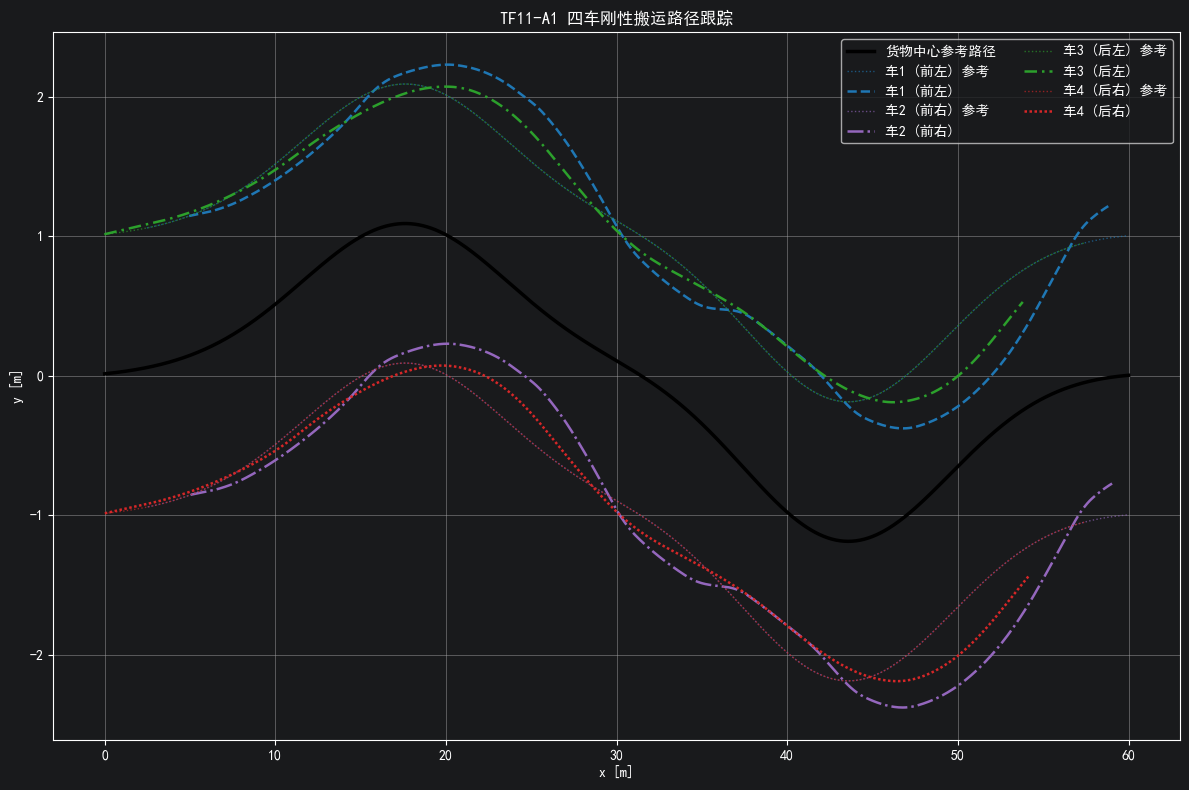

[A1][viz] 跳过实时动画（enable_realtime_animation=False）
=== 各车轨迹诊断 ===
车1 → 有效步数: 1001 | 最终s位置: 59.04 m | 参考终点s: 62.71 m
车2 → 有效步数: 1001 | 最终s位置: 59.23 m | 参考终点s: 62.71 m
车3 → 有效步数: 1001 | 最终s位置: 54.06 m | 参考终点s: 57.71 m
车4 → 有效步数: 1001 | 最终s位置: 54.24 m | 参考终点s: 57.71 m


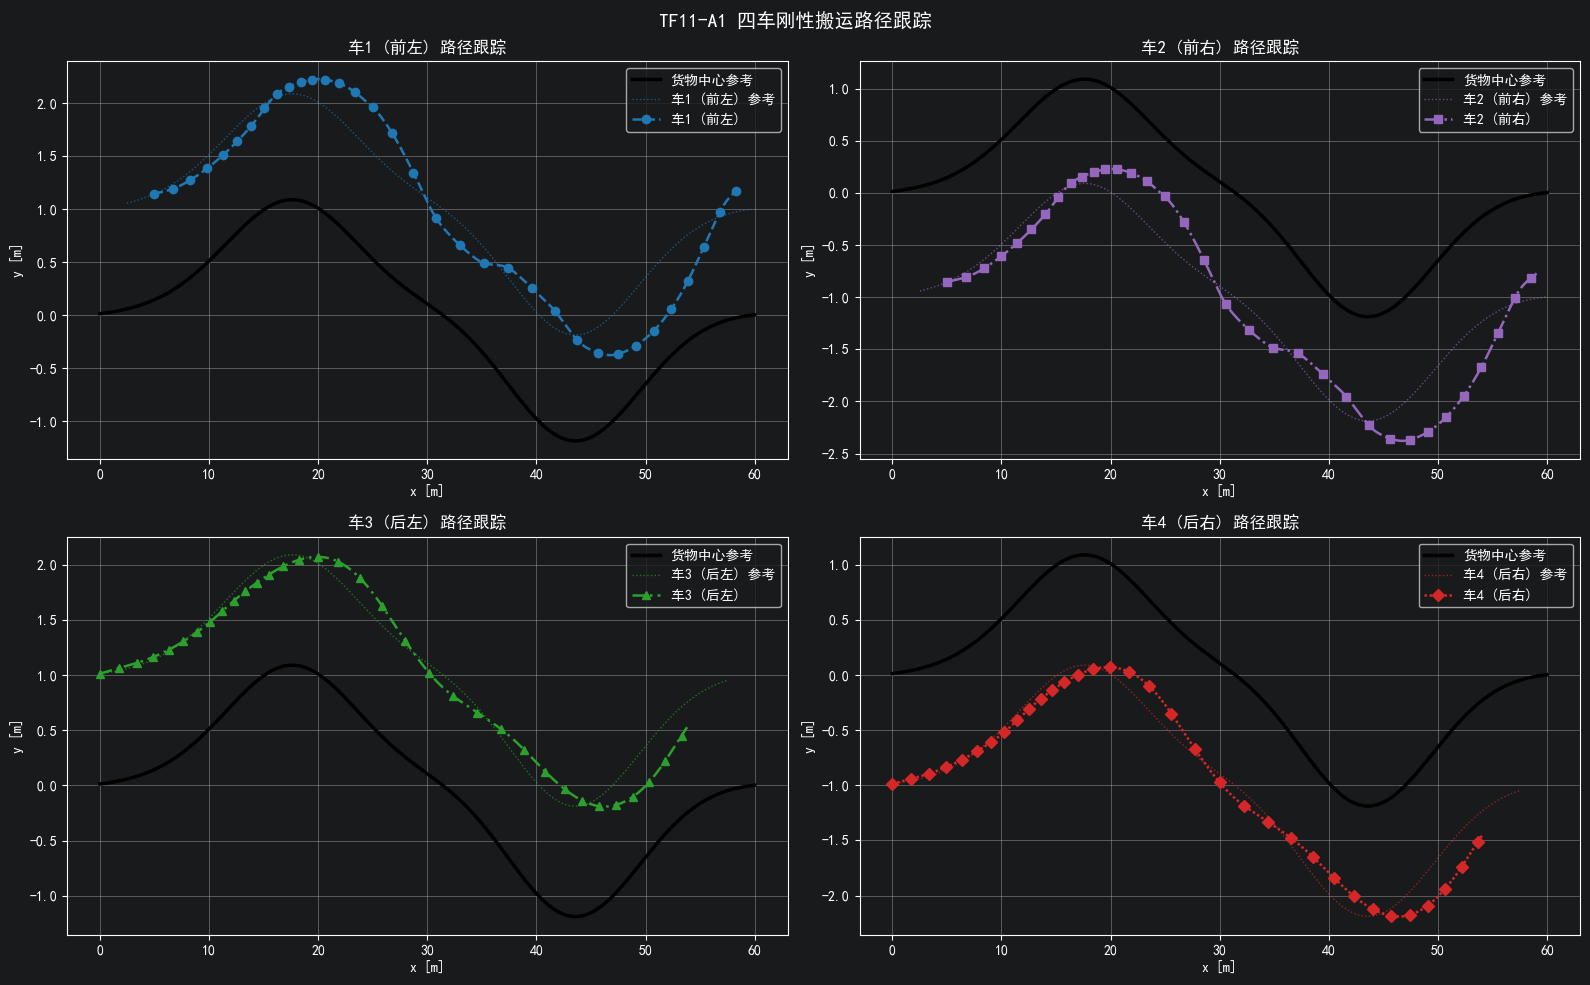

✅ 子图分开版已保存：inputs_separated.png


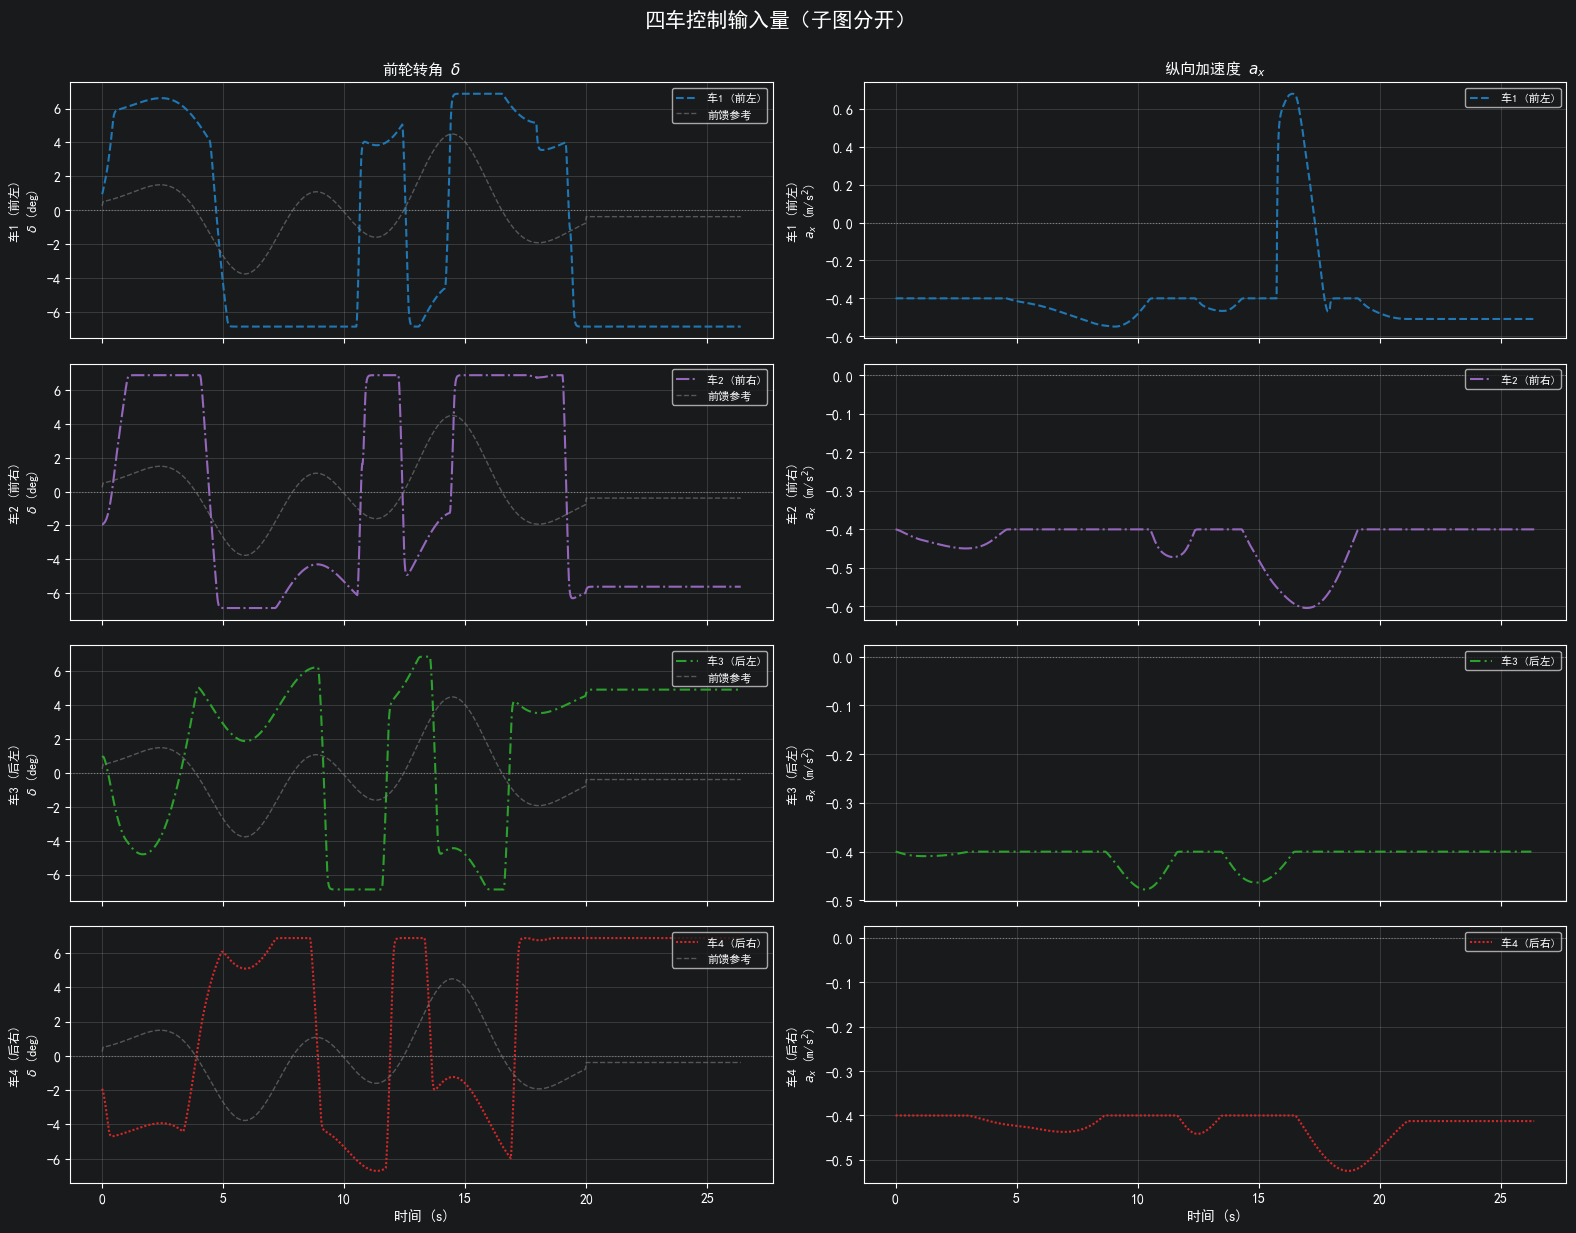

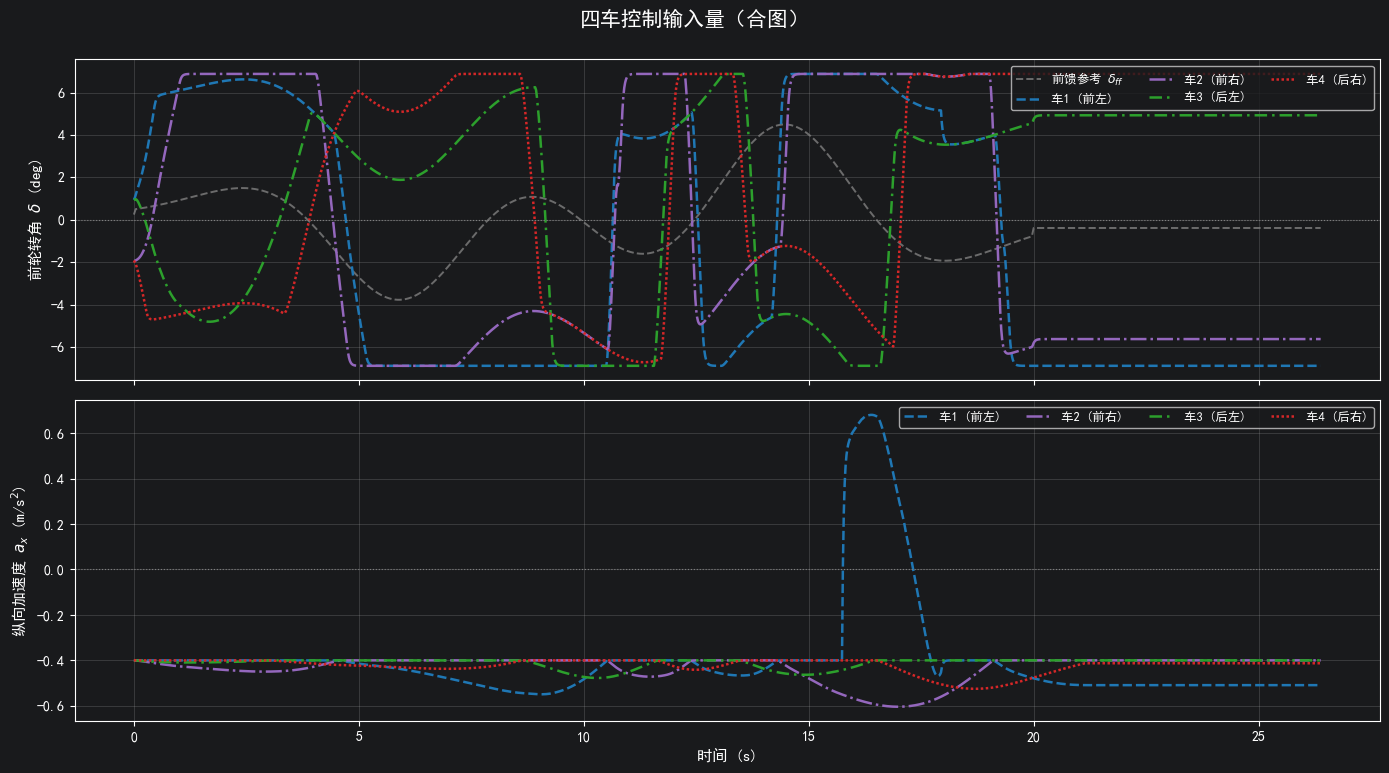

✅ 双轴子图版已保存：inputs_dual_axis.png


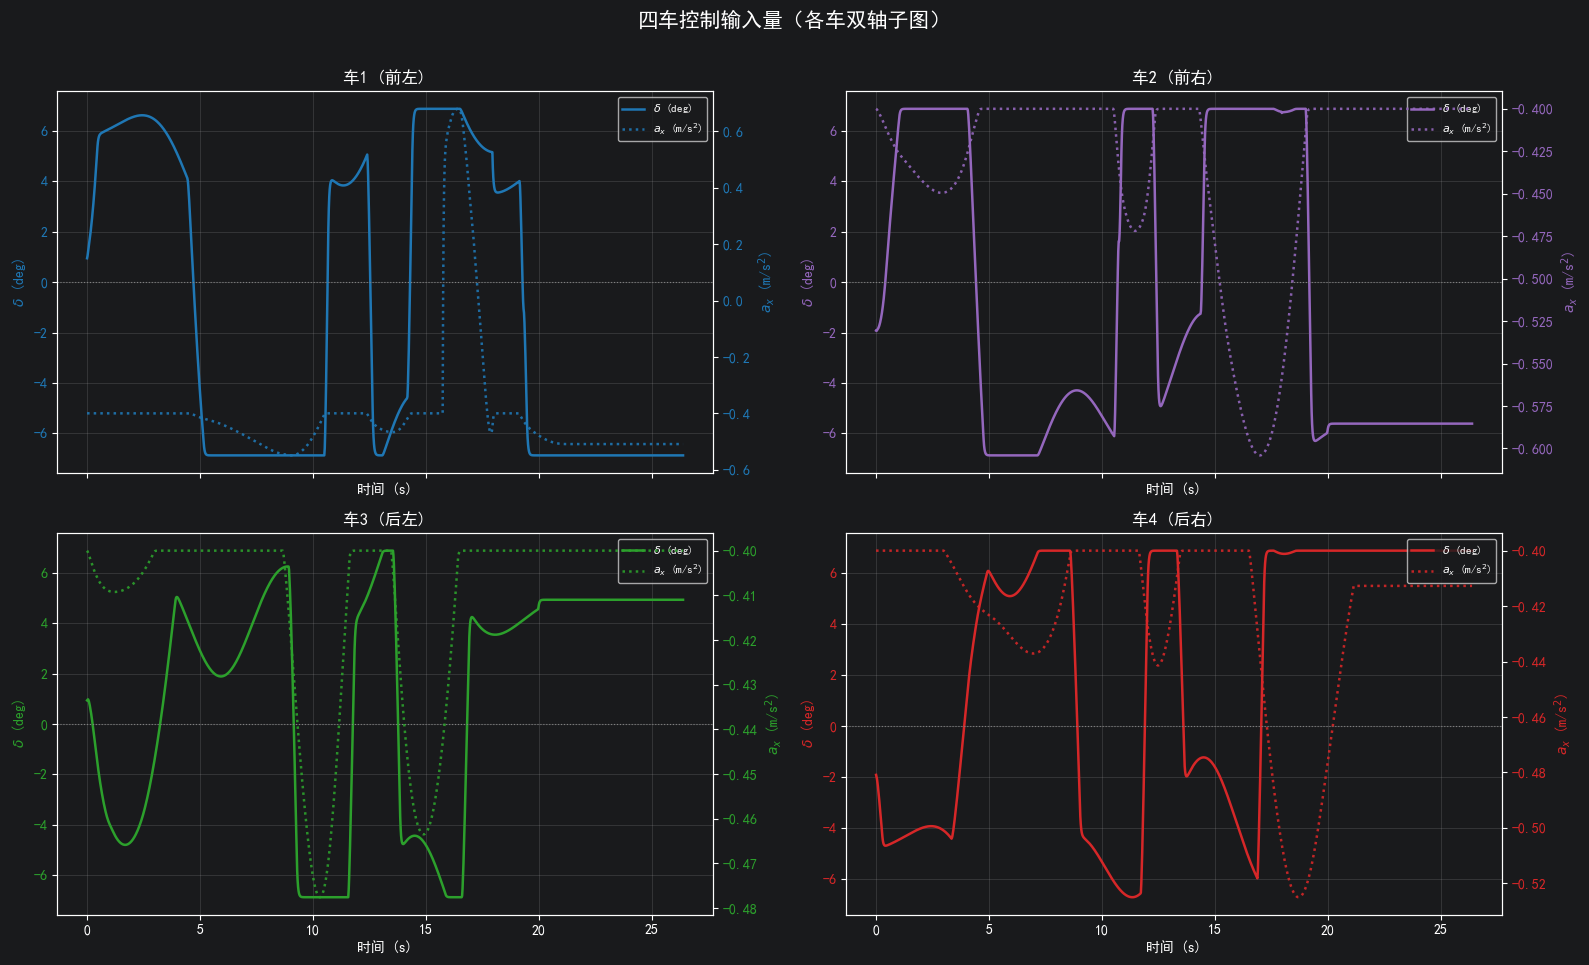

In [18]:

# =========================
# TF11-A1 可开关可视化（静态图 + 动画 + 输入图）
# =========================
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font", category=UserWarning)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

_TF11_A1_VIZ_DEFAULT = {
    # 路径图
    "enable_static_main_path": True,
    "enable_static_subplots": True,

    # 动画（最耗时，默认关）
    "enable_realtime_animation": False,
    "animation_embed_limit_mb": 40.0,
    "max_embed_frames": 420,
    "force_frame_step": None,

    # 输入图
    "enable_input_plots": True,
    "save_input_figures": True,
    "input_fig_dpi": 150,
}

_tf11_a1_viz_cfg_existing = globals().get('TF11_A1_VIZ_CFG', None)
if not isinstance(_tf11_a1_viz_cfg_existing, dict):
    TF11_A1_VIZ_CFG = dict(_TF11_A1_VIZ_DEFAULT)
else:
    _tmp_cfg = dict(_TF11_A1_VIZ_DEFAULT)
    _tmp_cfg.update(_tf11_a1_viz_cfg_existing)
    TF11_A1_VIZ_CFG = _tmp_cfg

print('[A1][viz] config =', TF11_A1_VIZ_CFG)

styles = [
    {'color': 'tab:blue', 'linestyle': '--', 'marker': 'o', 'linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.', 'marker': 's', 'linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green', 'linestyle': (0, (5, 2, 1, 2)), 'marker': '^', 'linewidth': 1.8, 'label': '车3 (后左)'},
    {'color': 'tab:red', 'linestyle': (0, (1, 1)), 'marker': 'D', 'linewidth': 1.8, 'label': '车4 (后右)'}
]

# =========================
# A) 静态总图
# =========================
if TF11_A1_VIZ_CFG['enable_static_main_path']:
    plt.figure(figsize=(12, 8))
    plt.plot(x_path, y_ref_path, label="货物中心参考路径", linewidth=2.5, color='black')

    for v in range(num_vehicles):
        n_hist = min(actual_sim_steps + 1, xt_actual_vehicles[v].shape[0], ref_vehicle_histories[v].shape[0])
        if n_hist <= 1:
            print(f"[WARN] 车{v + 1} 有效长度不足，无轨迹可画")
            continue

        s_ref_v = np.clip(ref_vehicle_histories[v][:n_hist, 0], s_ref_path.min() - 10.0, s_ref_path.max() + 10.0)
        ey_ref_v = ref_vehicle_histories[v][:n_hist, 1]
        x_ref_v, y_ref_v = frenet_to_global(s_ref_v, ey_ref_v, s_ref_path, x_path, y_ref_path, psi_ref_path)

        s_v = np.clip(xt_actual_vehicles[v][:n_hist, 0], s_ref_path.min() - 10.0, s_ref_path.max() + 10.0)
        ey_v = xt_actual_vehicles[v][:n_hist, 1]
        x_v, y_v = frenet_to_global(s_v, ey_v, s_ref_path, x_path, y_ref_path, psi_ref_path)

        plt.plot(
            x_ref_v, y_ref_v,
            color=styles[v]['color'], linestyle=':', linewidth=1.0, alpha=0.65,
            label=f"{styles[v]['label']} 参考"
        )
        plt.plot(
            x_v, y_v,
            color=styles[v]['color'], linestyle=styles[v]['linestyle'], linewidth=styles[v]['linewidth'],
            label=styles[v]['label']
        )

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("TF11-A1 四车刚性搬运路径跟踪")
    plt.legend(loc='upper right', ncol=2)
    plt.grid(True, alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print('[A1][viz] 跳过静态总图（enable_static_main_path=False）')

# =========================
# B) 动画（开关）
# =========================
if TF11_A1_VIZ_CFG['enable_realtime_animation']:
    from IPython.display import HTML, display
    import matplotlib as mpl
    import importlib
    import tf11_a1_realtime_viz as _tf11_a1_viz
    _tf11_a1_viz = importlib.reload(_tf11_a1_viz)

    mpl.rcParams['animation.embed_limit'] = max(
        float(mpl.rcParams.get('animation.embed_limit', 20.0)),
        float(TF11_A1_VIZ_CFG.get('animation_embed_limit_mb', 40.0))
    )

    anim_steps = int(main_result.get('sim_steps_cap', actual_sim_steps))
    run_steps = int(main_result.get('sim_steps', actual_sim_steps))
    if run_steps < anim_steps:
        print(f"[INFO] 主仿真提前结束: run_steps={run_steps}, sim_steps_cap={anim_steps}, full_path_reached={main_result.get('full_path_reached', False)}")
        print('[INFO] 动画将播放到 sim_steps_cap；提前结束后的时段会保持车辆末状态。')

    force_step = TF11_A1_VIZ_CFG.get('force_frame_step', None)
    if force_step is not None:
        frame_step = max(1, int(force_step))
    else:
        max_embed_frames = int(max(120, TF11_A1_VIZ_CFG.get('max_embed_frames', 420)))
        frame_step = max(1, int(np.ceil(anim_steps / max_embed_frames)))

    if frame_step > 1:
        print(f"[INFO] 动画抽帧启用: frame_step={frame_step} (总步数={anim_steps})")

    try:
        fig_anim, anim = _tf11_a1_viz.animate_a1_tracking_rectangles(
            xt_actual_vehicles=xt_actual_vehicles,
            ref_vehicle_histories=ref_vehicle_histories,
            actual_sim_steps=anim_steps,
            s_ref_path=s_ref_path,
            x_path=x_path,
            y_ref_path=y_ref_path,
            psi_ref_path=psi_ref_path,
            frenet_to_global=frenet_to_global,
            dt=dt,
            vehicle_length=4.4,
            vehicle_width=1.9,
            tail_points=max(60, int(140 / frame_step)),
            frame_step=frame_step,
            interval_ms=max(20, int(1000 * dt * frame_step)),
            figsize=(10.5, 5.2),
            dark_theme=True,
            show_vehicle_refs=True,
        )
        fps_show = max(8, int(round(1.0 / max(dt * frame_step, 1e-6))))
        display(HTML(anim.to_jshtml(fps=fps_show)))
        plt.close(fig_anim)
    except Exception as e:
        print(f"[WARN] 实时动画生成失败: {e}")
else:
    print('[A1][viz] 跳过实时动画（enable_realtime_animation=False）')

# =========================
# C) 轨迹诊断（轻量，始终保留）
# =========================
print("=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    n_hist = min(actual_sim_steps + 1, xt_actual_vehicles[v].shape[0], ref_vehicle_histories[v].shape[0])
    if n_hist > 0:
        final_s = xt_actual_vehicles[v][n_hist - 1, 0]
        ref_final_s = ref_vehicle_histories[v][n_hist - 1, 0]
        print(f"车{v + 1} → 有效步数: {n_hist} | 最终s位置: {final_s:.2f} m | 参考终点s: {ref_final_s:.2f} m")
    else:
        print(f"车{v + 1} → 无有效轨迹")

# =========================
# D) 四子图路径（开关）
# =========================
if TF11_A1_VIZ_CFG['enable_static_subplots']:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    styles = [
        {'color': 'tab:blue', 'linestyle': '--', 'marker': 'o', 'markevery': 30, 'linewidth': 1.8, 'label': '车1 (前左)'},
        {'color': 'tab:purple', 'linestyle': '-.', 'marker': 's', 'markevery': 30, 'linewidth': 1.8, 'label': '车2 (前右)'},
        {'color': 'tab:green', 'linestyle': (0, (5, 2, 1, 2)), 'marker': '^', 'markevery': 30, 'linewidth': 1.8, 'label': '车3 (后左)'},
        {'color': 'tab:red', 'linestyle': (0, (1, 1)), 'marker': 'D', 'markevery': 30, 'linewidth': 1.8, 'label': '车4 (后右)'}
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for v in range(num_vehicles):
        ax = axes[v]
        ax.plot(x_path, y_ref_path, label="货物中心参考", linewidth=2.5, color='black', linestyle='-')

        n_hist = min(actual_sim_steps + 1, xt_actual_vehicles[v].shape[0], ref_vehicle_histories[v].shape[0])
        if n_hist <= 1:
            ax.set_title(f"车{v + 1} - 轨迹无效")
            continue

        s_ref_v = np.clip(ref_vehicle_histories[v][:n_hist, 0], s_ref_path.min() - 10.0, s_ref_path.max() + 10.0)
        ey_ref_v = ref_vehicle_histories[v][:n_hist, 1]
        x_ref_v, y_ref_v = frenet_to_global(s_ref_v, ey_ref_v, s_ref_path, x_path, y_ref_path, psi_ref_path)

        s_v = np.clip(xt_actual_vehicles[v][:n_hist, 0], s_ref_path.min() - 10.0, s_ref_path.max() + 10.0)
        ey_v = xt_actual_vehicles[v][:n_hist, 1]
        x_v, y_v = frenet_to_global(s_v, ey_v, s_ref_path, x_path, y_ref_path, psi_ref_path)

        ax.plot(x_ref_v, y_ref_v, color=styles[v]['color'], linestyle=':', linewidth=1.0, alpha=0.65, label=f"{styles[v]['label']} 参考")
        ax.plot(
            x_v, y_v,
            color=styles[v]['color'], linestyle=styles[v]['linestyle'], marker=styles[v]['marker'],
            markevery=styles[v]['markevery'], linewidth=styles[v]['linewidth'], label=styles[v]['label']
        )

        ax.set_title(f"{styles[v]['label']} 路径跟踪")
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.6)

    fig.suptitle("TF11-A1 四车刚性搬运路径跟踪", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('[A1][viz] 跳过四子图路径（enable_static_subplots=False）')

# =========================
# E) 输入量图（开关）
# =========================
if TF11_A1_VIZ_CFG['enable_input_plots']:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    N_ctrl = u_vehicles[0].shape[0]
    t_ctrl = np.arange(N_ctrl) * dt

    if curvature_ref_path.shape[0] == 0:
        curvature_ff = np.zeros(N_ctrl)
    elif curvature_ref_path.shape[0] >= N_ctrl:
        curvature_ff = curvature_ref_path[:N_ctrl]
    else:
        curvature_ff = np.pad(curvature_ref_path, (0, N_ctrl - curvature_ref_path.shape[0]), mode='edge')

    delta_ff_ref_shared = 0.8 * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ff

    colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
    labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
    ls_v = ['--', '-.', (0, (5, 2, 1, 2)), (0, (1, 1))]

    fig1, axes1 = plt.subplots(nrows=num_vehicles, ncols=2, figsize=(16, 3.2 * num_vehicles), sharex=True)
    fig1.suptitle('四车控制输入量（子图分开）', fontsize=15, fontweight='bold')

    for v in range(num_vehicles):
        delta_v = u_vehicles[v][:, 0]
        ax_v = u_vehicles[v][:, 1]

        ax_left = axes1[v, 0]
        ax_left.plot(t_ctrl, np.rad2deg(delta_v), color=colors_v[v], linestyle=ls_v[v], linewidth=1.5, label=labels_v[v])
        ax_left.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax_left.plot(t_ctrl, np.rad2deg(delta_ff_ref_shared), color='gray', linewidth=1.0, linestyle='--', alpha=0.6, label='前馈参考')
        ax_left.set_ylabel(labels_v[v] + "\n$\\delta$ (deg)", fontsize=9)
        ax_left.legend(fontsize=8, loc='upper right')
        ax_left.grid(True, alpha=0.3)
        if v == 0:
            ax_left.set_title('前轮转角 $\\delta$', fontsize=11)
        if v == num_vehicles - 1:
            ax_left.set_xlabel('时间 (s)', fontsize=10)

        ax_right = axes1[v, 1]
        ax_right.plot(t_ctrl, ax_v, color=colors_v[v], linestyle=ls_v[v], linewidth=1.5, label=labels_v[v])
        ax_right.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax_right.set_ylabel(labels_v[v] + "\n$a_x$ (m/s$^2$)", fontsize=9)
        ax_right.legend(fontsize=8, loc='upper right')
        ax_right.grid(True, alpha=0.3)
        if v == 0:
            ax_right.set_title('纵向加速度 $a_x$', fontsize=11)
        if v == num_vehicles - 1:
            ax_right.set_xlabel('时间 (s)', fontsize=10)

    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    if TF11_A1_VIZ_CFG['save_input_figures']:
        plt.savefig('inputs_separated.png', dpi=int(TF11_A1_VIZ_CFG.get('input_fig_dpi', 150)), bbox_inches='tight')
        print('✅ 子图分开版已保存：inputs_separated.png')
    plt.show()

    fig2, (ax_top, ax_bot) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)
    fig2.suptitle('四车控制输入量（合图）', fontsize=15, fontweight='bold')

    ax_top.plot(t_ctrl, np.rad2deg(delta_ff_ref_shared), color='gray', linewidth=1.4, linestyle='--', alpha=0.8, label='前馈参考 $\\delta_{ff}$')
    for v in range(num_vehicles):
        delta_v = u_vehicles[v][:, 0]
        ax_top.plot(t_ctrl, np.rad2deg(delta_v), color=colors_v[v], linestyle=ls_v[v], linewidth=1.8, label=labels_v[v])
    ax_top.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax_top.set_ylabel('前轮转角 $\\delta$ (deg)', fontsize=11)
    ax_top.grid(True, alpha=0.3)
    ax_top.legend(fontsize=9, ncol=3, loc='upper right')

    for v in range(num_vehicles):
        ax_v = u_vehicles[v][:, 1]
        ax_bot.plot(t_ctrl, ax_v, color=colors_v[v], linestyle=ls_v[v], linewidth=1.8, label=labels_v[v])
    ax_bot.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax_bot.set_ylabel('纵向加速度 $a_x$ (m/s$^2$)', fontsize=11)
    ax_bot.set_xlabel('时间 (s)', fontsize=11)
    ax_bot.grid(True, alpha=0.3)
    ax_bot.legend(fontsize=9, ncol=4, loc='upper right')

    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    plt.show()

    fig3, axes3 = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharex=True)
    fig3.suptitle('四车控制输入量（各车双轴子图）', fontsize=15, fontweight='bold')
    axes3 = axes3.flatten()

    for v in range(num_vehicles):
        ax_main = axes3[v]
        delta_v = np.rad2deg(u_vehicles[v][:, 0])
        ax_v = u_vehicles[v][:, 1]

        ax_main.plot(t_ctrl, delta_v, color=colors_v[v], linestyle='-', linewidth=1.8, label='$\\delta$ (deg)')
        ax_main.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax_main.set_ylabel('$\\delta$ (deg)', color=colors_v[v], fontsize=10)
        ax_main.tick_params(axis='y', labelcolor=colors_v[v])
        ax_main.grid(True, alpha=0.25)

        ax_twin = ax_main.twinx()
        ax_twin.plot(t_ctrl, ax_v, color=colors_v[v], linestyle=':', linewidth=1.8, alpha=0.9, label='$a_x$ (m/s$^2$)')
        ax_twin.set_ylabel('$a_x$ (m/s$^2$)', color=colors_v[v], fontsize=10)
        ax_twin.tick_params(axis='y', labelcolor=colors_v[v])

        ax_main.set_title(labels_v[v], fontsize=12, fontweight='bold')
        ax_main.set_xlabel('时间 (s)', fontsize=10)

        h1, l1 = ax_main.get_legend_handles_labels()
        h2, l2 = ax_twin.get_legend_handles_labels()
        ax_main.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')

    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    if TF11_A1_VIZ_CFG['save_input_figures']:
        plt.savefig('inputs_dual_axis.png', dpi=int(TF11_A1_VIZ_CFG.get('input_fig_dpi', 150)), bbox_inches='tight')
        print('✅ 双轴子图版已保存：inputs_dual_axis.png')
    plt.show()
else:
    print('[A1][viz] 跳过输入图（enable_input_plots=False）')


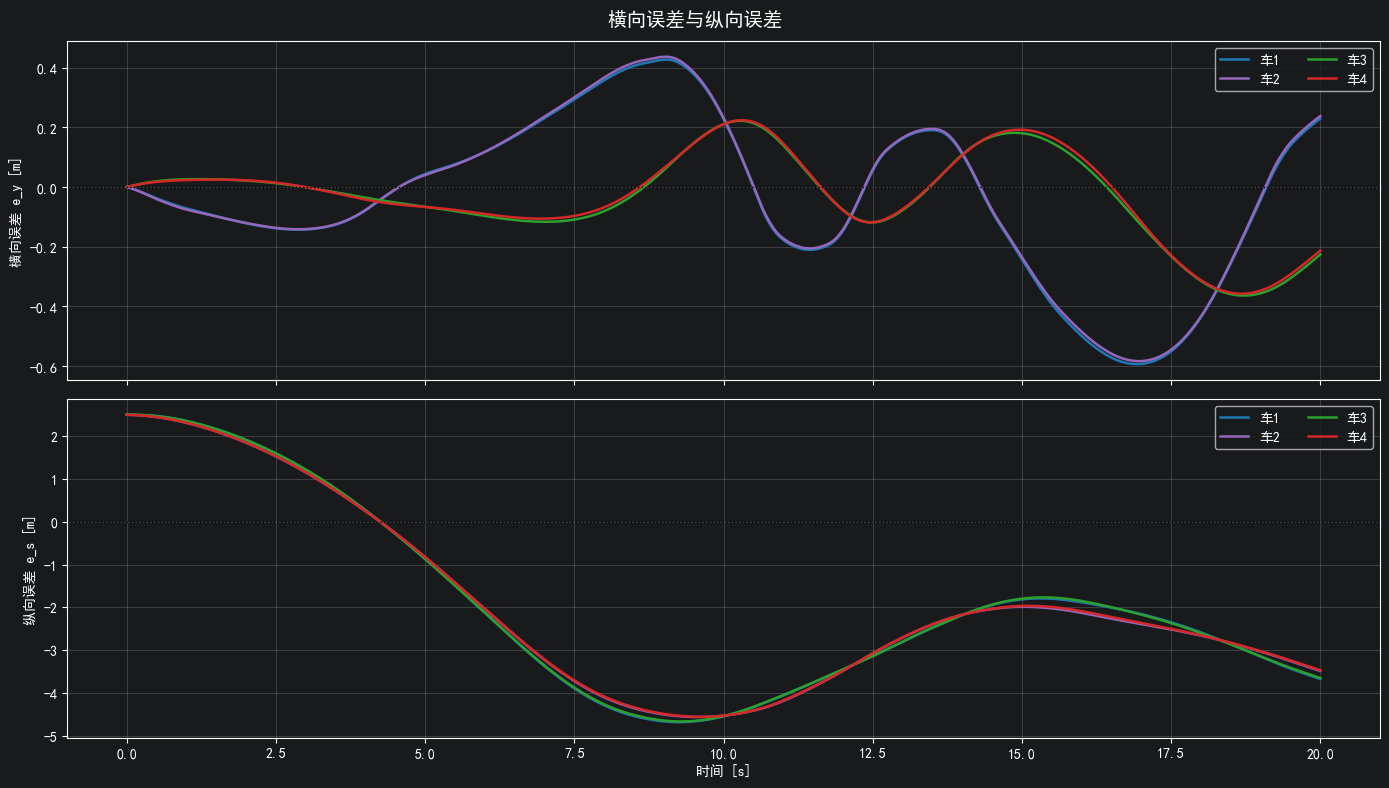

=== 误差统计（相对于刚体四角参考）===
车1: RMSE(e_y)=0.2680 m, Max|e_y|=0.5933 m | RMSE(e_s)=2.8869 m, Max|e_s|=4.6778 m
车2: RMSE(e_y)=0.2669 m, Max|e_y|=0.5832 m | RMSE(e_s)=2.8620 m, Max|e_s|=4.5576 m
车3: RMSE(e_y)=0.1484 m, Max|e_y|=0.3637 m | RMSE(e_s)=2.8794 m, Max|e_s|=4.6615 m
车4: RMSE(e_y)=0.1468 m, Max|e_y|=0.3573 m | RMSE(e_s)=2.8528 m, Max|e_s|=4.5534 m


In [19]:
# =========================
# TF11-A1 横向误差与纵向误差
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('横向误差与纵向误差', fontsize=14, fontweight='bold')

colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
labels_v = ['车1', '车2', '车3', '车4']
err_stats = []

for v in range(num_vehicles):
    x_hist_full = xt_actual_vehicles[v]
    ref_hist_full = ref_vehicle_histories[v]
    n_hist = min(actual_sim_steps + 1, x_hist_full.shape[0], ref_hist_full.shape[0])
    if n_hist <= 1:
        print(f"车{v+1}: 无有效误差数据")
        continue

    x_hist = x_hist_full[:n_hist, :]
    ref_hist = ref_hist_full[:n_hist, :]
    t_eval = np.arange(n_hist) * dt

    e_long = x_hist[:, 0] - ref_hist[:, 0]
    e_lat = x_hist[:, 1] - ref_hist[:, 1]

    valid = np.isfinite(e_long) & np.isfinite(e_lat)
    if not np.any(valid):
        print(f"车{v+1}: 无有效误差数据")
        continue

    c = colors_v[v % len(colors_v)]
    label = labels_v[v] if v < len(labels_v) else f'车{v+1}'

    ax1.plot(t_eval[valid], e_lat[valid], color=c, linewidth=1.8, label=label)
    ax2.plot(t_eval[valid], e_long[valid], color=c, linewidth=1.8, label=label)

    rmse_lat = float(np.sqrt(np.mean(e_lat[valid] ** 2)))
    rmse_long = float(np.sqrt(np.mean(e_long[valid] ** 2)))
    max_lat = float(np.max(np.abs(e_lat[valid])))
    max_long = float(np.max(np.abs(e_long[valid])))
    err_stats.append((v + 1, rmse_lat, max_lat, rmse_long, max_long))

ax1.axhline(0.0, color='black', linestyle=':', linewidth=1.0)
ax2.axhline(0.0, color='black', linestyle=':', linewidth=1.0)
ax1.set_ylabel('横向误差 e_y [m]')
ax2.set_ylabel('纵向误差 e_s [m]')
ax2.set_xlabel('时间 [s]')
ax1.grid(True, alpha=0.35)
ax2.grid(True, alpha=0.35)
ax1.legend(loc='upper right', ncol=min(2, num_vehicles))
ax2.legend(loc='upper right', ncol=min(2, num_vehicles))

plt.tight_layout()
plt.show()

print("=== 误差统计（相对于刚体四角参考）===")
for vid, rmse_lat, max_lat, rmse_long, max_long in err_stats:
    print(
        f"车{vid}: "
        f"RMSE(e_y)={rmse_lat:.4f} m, Max|e_y|={max_lat:.4f} m | "
        f"RMSE(e_s)={rmse_long:.4f} m, Max|e_s|={max_long:.4f} m"
    )


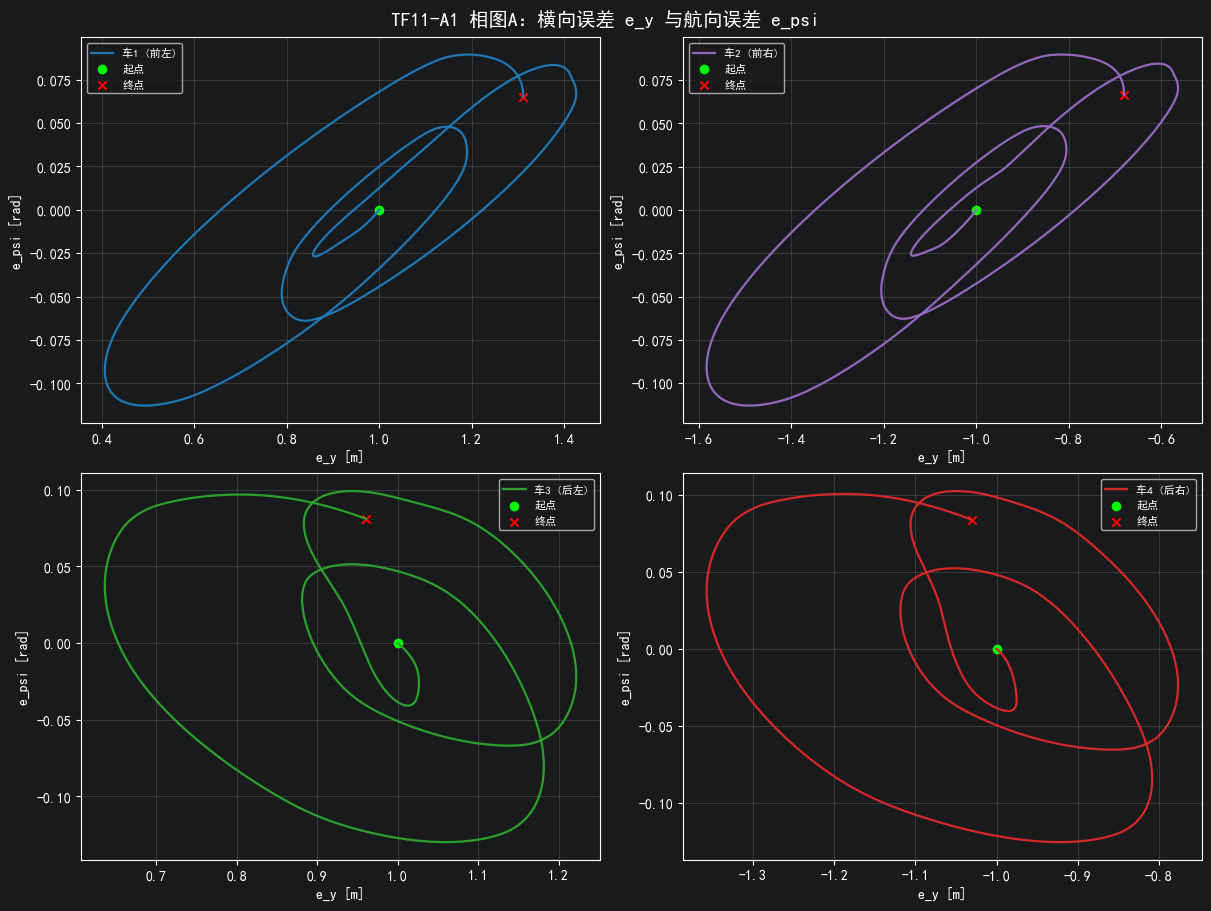

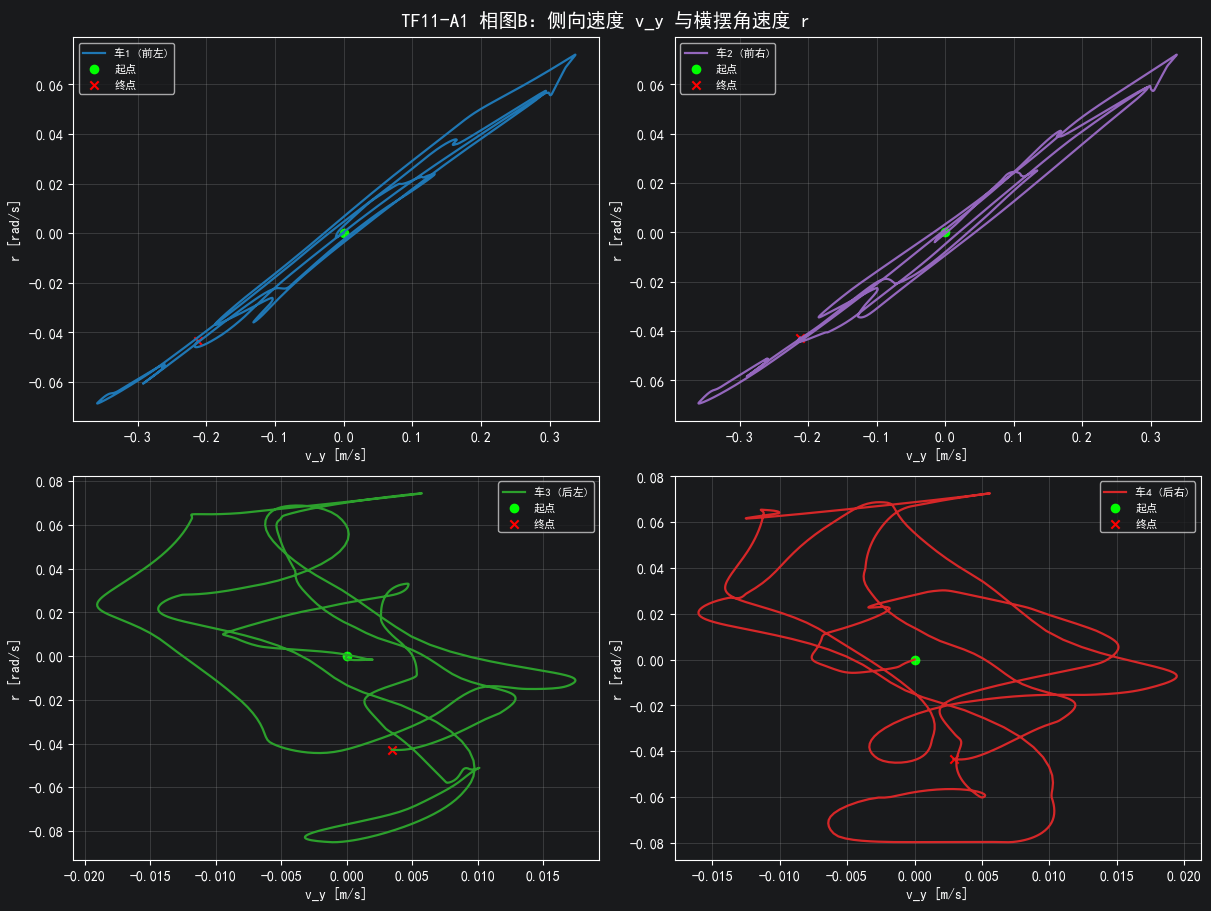

In [20]:
# =========================
# TF11-A1 相图分析（Phase Portrait）
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

if 'xt_actual_vehicles' not in globals():
    raise RuntimeError('xt_actual_vehicles 不存在，请先运行 TF11-A1 主方法与结果回填单元。')

sim_steps_eval = int(main_result.get('sim_steps', xt_actual_vehicles[0].shape[0] - 1))
labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
colors = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']

# 1) e_y - e_psi 相图
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle('TF11-A1 相图A：横向误差 e_y 与航向误差 e_psi', fontsize=14, fontweight='bold')

for v in range(num_vehicles):
    ax = axes[v // 2, v % 2]
    x_hist = xt_actual_vehicles[v][:sim_steps_eval + 1, :]
    ey = x_hist[:, 1]
    epsi = x_hist[:, 2]

    ax.plot(ey, epsi, color=colors[v], linewidth=1.6, label=labels_v[v])
    ax.scatter(ey[0], epsi[0], color='lime', s=36, marker='o', label='起点')
    ax.scatter(ey[-1], epsi[-1], color='red', s=36, marker='x', label='终点')
    ax.set_xlabel('e_y [m]')
    ax.set_ylabel('e_psi [rad]')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.show()

# 2) v_y - r 相图（侧向速度-横摆角速度）
if xt_actual_vehicles[0].shape[1] >= 6:
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    fig.suptitle('TF11-A1 相图B：侧向速度 v_y 与横摆角速度 r', fontsize=14, fontweight='bold')

    for v in range(num_vehicles):
        ax = axes[v // 2, v % 2]
        x_hist = xt_actual_vehicles[v][:sim_steps_eval + 1, :]
        vy = x_hist[:, 4]
        r = x_hist[:, 5]

        ax.plot(vy, r, color=colors[v], linewidth=1.6, label=labels_v[v])
        ax.scatter(vy[0], r[0], color='lime', s=36, marker='o', label='起点')
        ax.scatter(vy[-1], r[-1], color='red', s=36, marker='x', label='终点')
        ax.set_xlabel('v_y [m/s]')
        ax.set_ylabel('r [rad/s]')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')

    plt.show()
else:
    print('[TF11-A1 相图B] 状态维度 < 6，跳过 v_y-r 相图。')




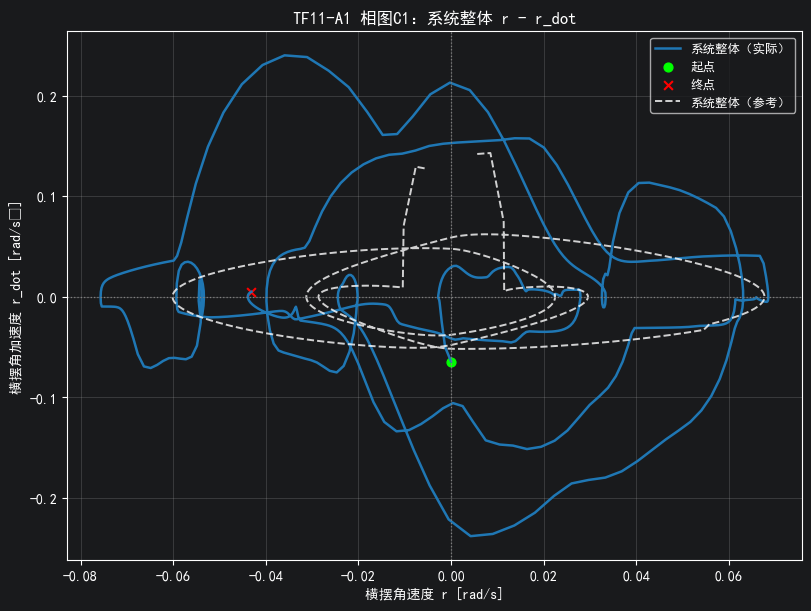

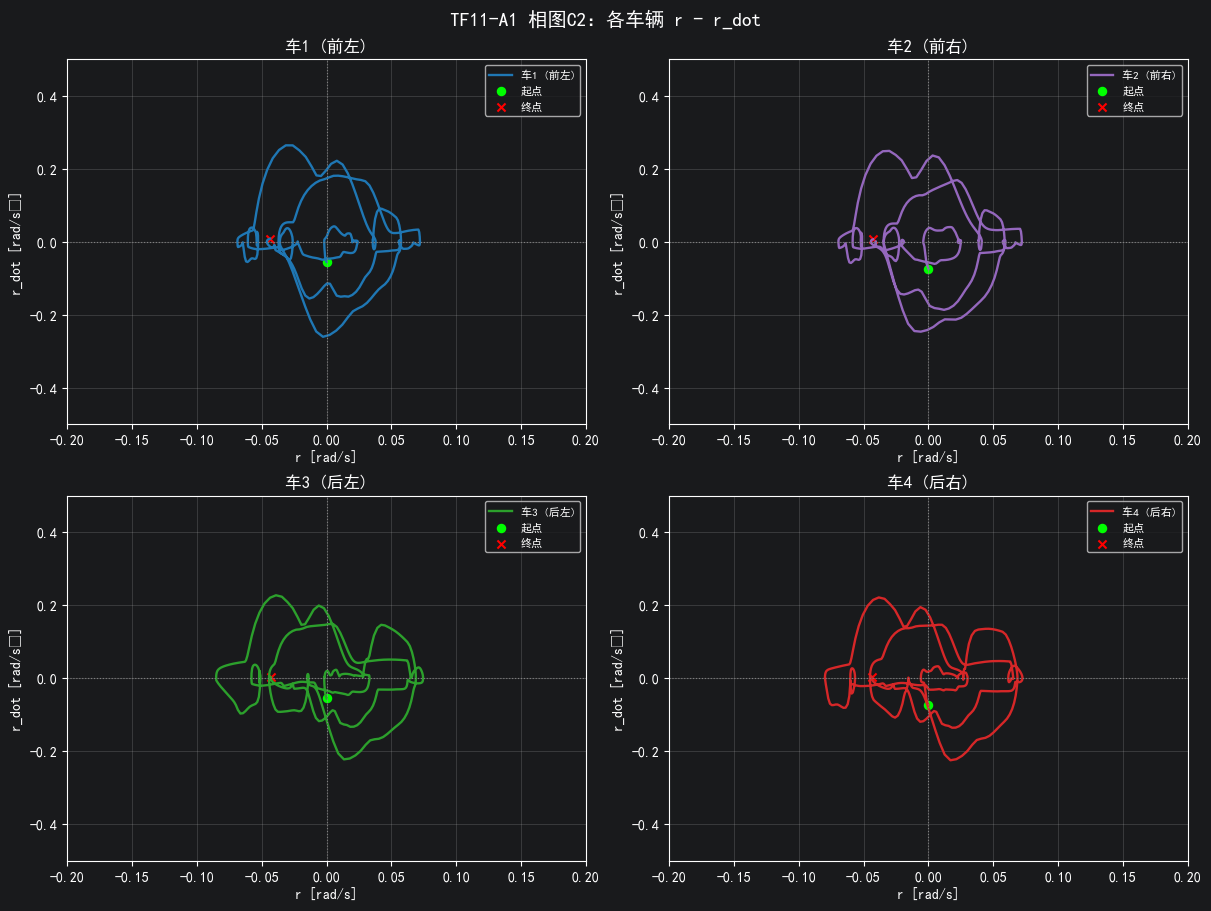

=== r-r_dot 相图统计 ===
系统整体: max|r|=0.0757, max|r_dot|=0.2401
车1: max|r|=0.0720, max|r_dot|=0.2642
车2: max|r|=0.0721, max|r_dot|=0.2490
车3: max|r|=0.0852, max|r_dot|=0.2270
车4: max|r|=0.0798, max|r_dot|=0.2249


In [21]:
# =========================
# TF11-A1 相图C：横摆角速度 r 与横摆角加速度 r_dot
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

if 'main_result' not in globals() or main_result is None:
    raise RuntimeError('main_result 不存在，请先运行 TF11-A1 主方法单元。')
if 'xt_actual_vehicles' not in globals() or len(xt_actual_vehicles) == 0:
    raise RuntimeError('xt_actual_vehicles 不存在，请先运行结果回填单元。')
if 'dt' not in globals():
    raise RuntimeError('dt 不存在，请先运行基础配置与建模单元。')

sim_steps_phase = int(main_result.get('sim_steps', xt_actual_vehicles[0].shape[0] - 1))
sim_steps_phase = max(1, sim_steps_phase)


from control_files.tf11_a1.core_utils import calc_r_and_rdot as _calc_r_and_rdot


# 1) 系统整体相平面（团队状态）
if 'team_state_hist' in globals() and isinstance(team_state_hist, np.ndarray) and team_state_hist.shape[1] >= 6:
    n_team = min(sim_steps_phase + 1, team_state_hist.shape[0])
    r_team, rdot_team = _calc_r_and_rdot(team_state_hist[:n_team, 5], dt)
else:
    r_team = np.array([])
    rdot_team = np.array([])

r_ref = np.array([])
rdot_ref = np.array([])
if 'ref_team_hist' in globals() and isinstance(ref_team_hist, np.ndarray) and ref_team_hist.shape[1] >= 6:
    n_ref = min(sim_steps_phase + 1, ref_team_hist.shape[0])
    r_ref, rdot_ref = _calc_r_and_rdot(ref_team_hist[:n_ref, 5], dt)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
if r_team.size > 0:
    ax.plot(r_team, rdot_team, color='tab:blue', linewidth=1.8, label='系统整体（实际）')
    ax.scatter(r_team[0], rdot_team[0], color='lime', s=40, marker='o', label='起点')
    ax.scatter(r_team[-1], rdot_team[-1], color='red', s=40, marker='x', label='终点')
if r_ref.size > 0:
    ax.plot(r_ref, rdot_ref, color='white', linestyle='--', linewidth=1.4, alpha=0.8, label='系统整体（参考）')

ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.9)
ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.9)
ax.set_xlabel('横摆角速度 r [rad/s]')
ax.set_ylabel('横摆角加速度 r_dot [rad/s²]')
ax.set_title('TF11-A1 相图C1：系统整体 r - r_dot')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.show()

# 2) 各车辆相平面（四子图）
labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']

veh_curves = []
for v in range(num_vehicles):
    x_hist = np.asarray(xt_actual_vehicles[v], dtype=float)
    n_hist = min(sim_steps_phase + 1, x_hist.shape[0])
    if n_hist <= 1 or x_hist.shape[1] < 6:
        veh_curves.append((np.array([]), np.array([])))
        continue
    r_v, rdot_v = _calc_r_and_rdot(x_hist[:n_hist, 5], dt)
    veh_curves.append((r_v, rdot_v))

# 统一轴范围，方便对比
r_all = np.concatenate([c[0] for c in veh_curves if c[0].size > 0], axis=0) if any(c[0].size > 0 for c in veh_curves) else np.array([0.0])
rdot_all = np.concatenate([c[1] for c in veh_curves if c[1].size > 0], axis=0) if any(c[1].size > 0 for c in veh_curves) else np.array([0.0])
r_lim = max(0.2, float(np.max(np.abs(r_all))) * 1.15)
rdot_lim = max(0.5, float(np.max(np.abs(rdot_all))) * 1.15)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
fig.suptitle('TF11-A1 相图C2：各车辆 r - r_dot', fontsize=14, fontweight='bold')

for v in range(num_vehicles):
    ax = axes[v // 2, v % 2]
    r_v, rdot_v = veh_curves[v]
    if r_v.size <= 1:
        ax.set_title(f'{labels_v[v]}（数据不足）')
        ax.grid(True, alpha=0.3)
        continue

    ax.plot(r_v, rdot_v, color=colors_v[v], linewidth=1.7, label=labels_v[v])
    ax.scatter(r_v[0], rdot_v[0], color='lime', s=34, marker='o', label='起点')
    ax.scatter(r_v[-1], rdot_v[-1], color='red', s=34, marker='x', label='终点')

    ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlim(-r_lim, r_lim)
    ax.set_ylim(-rdot_lim, rdot_lim)
    ax.set_xlabel('r [rad/s]')
    ax.set_ylabel('r_dot [rad/s²]')
    ax.set_title(labels_v[v])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

plt.show()

print('=== r-r_dot 相图统计 ===')
if r_team.size > 0:
    print(f'系统整体: max|r|={np.max(np.abs(r_team)):.4f}, max|r_dot|={np.max(np.abs(rdot_team)):.4f}')
for v in range(num_vehicles):
    r_v, rdot_v = veh_curves[v]
    if r_v.size > 0:
        print(f'车{v+1}: max|r|={np.max(np.abs(r_v)):.4f}, max|r_dot|={np.max(np.abs(rdot_v)):.4f}')



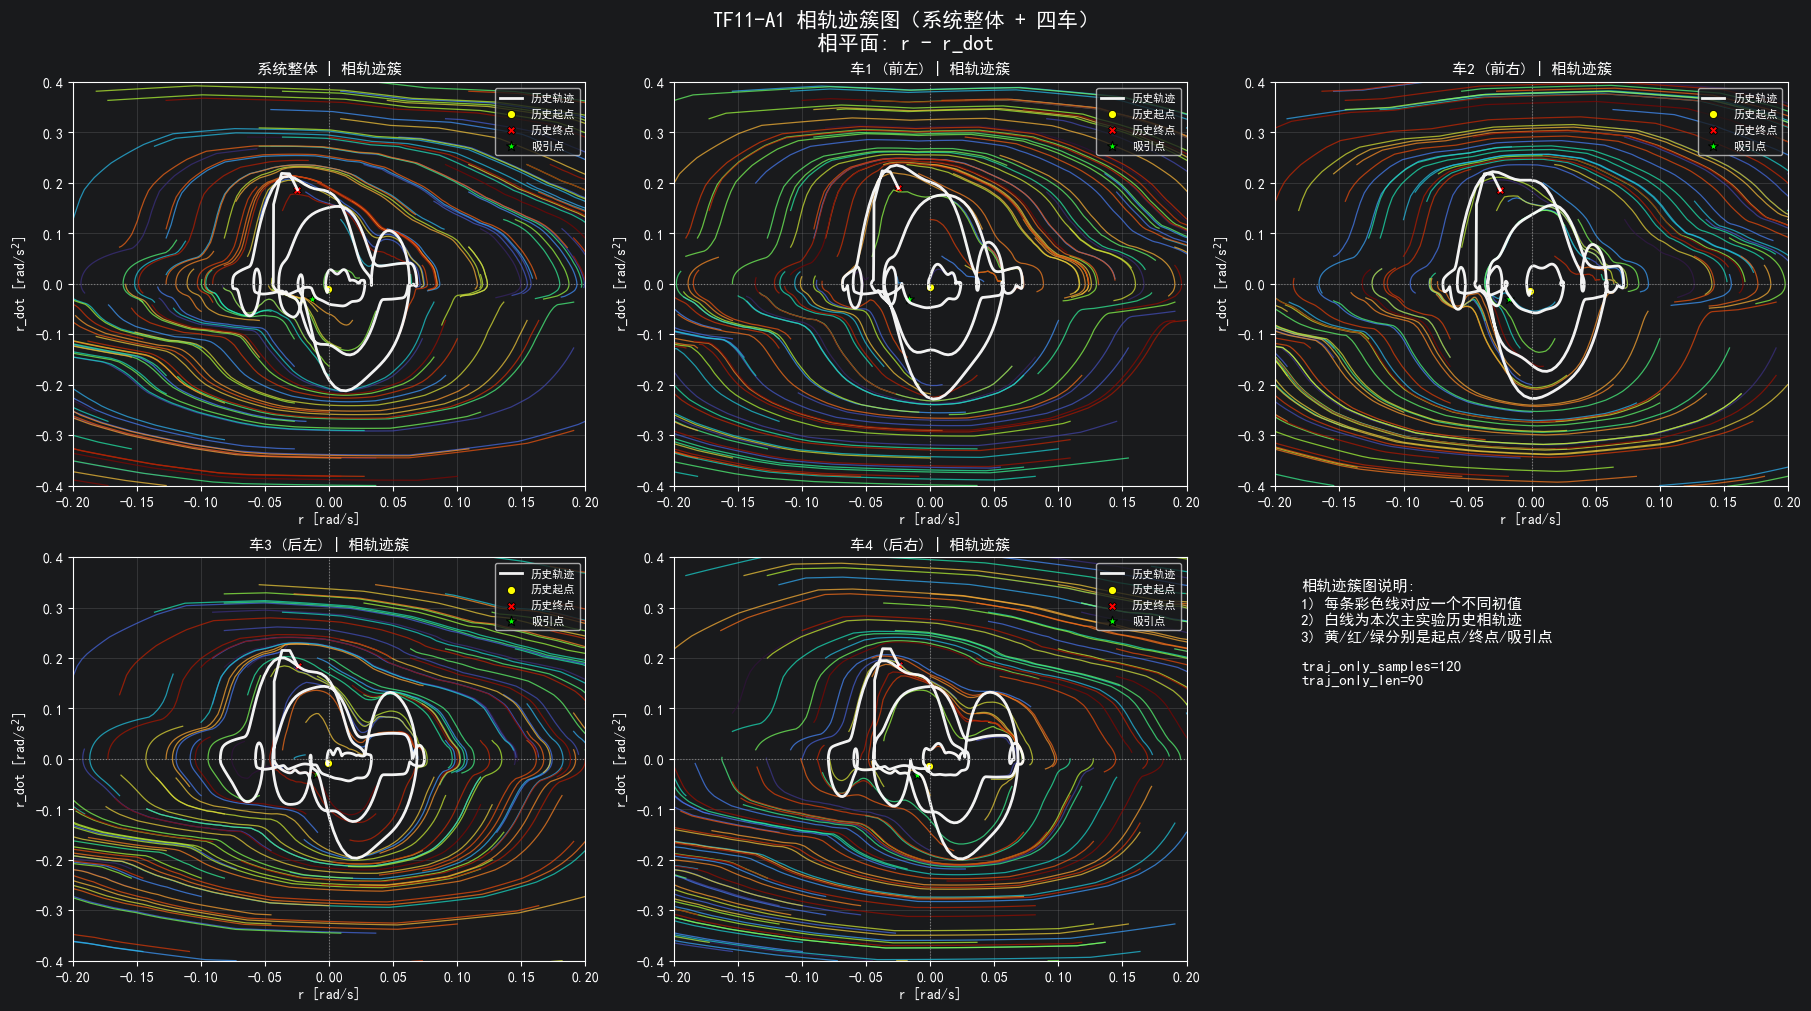

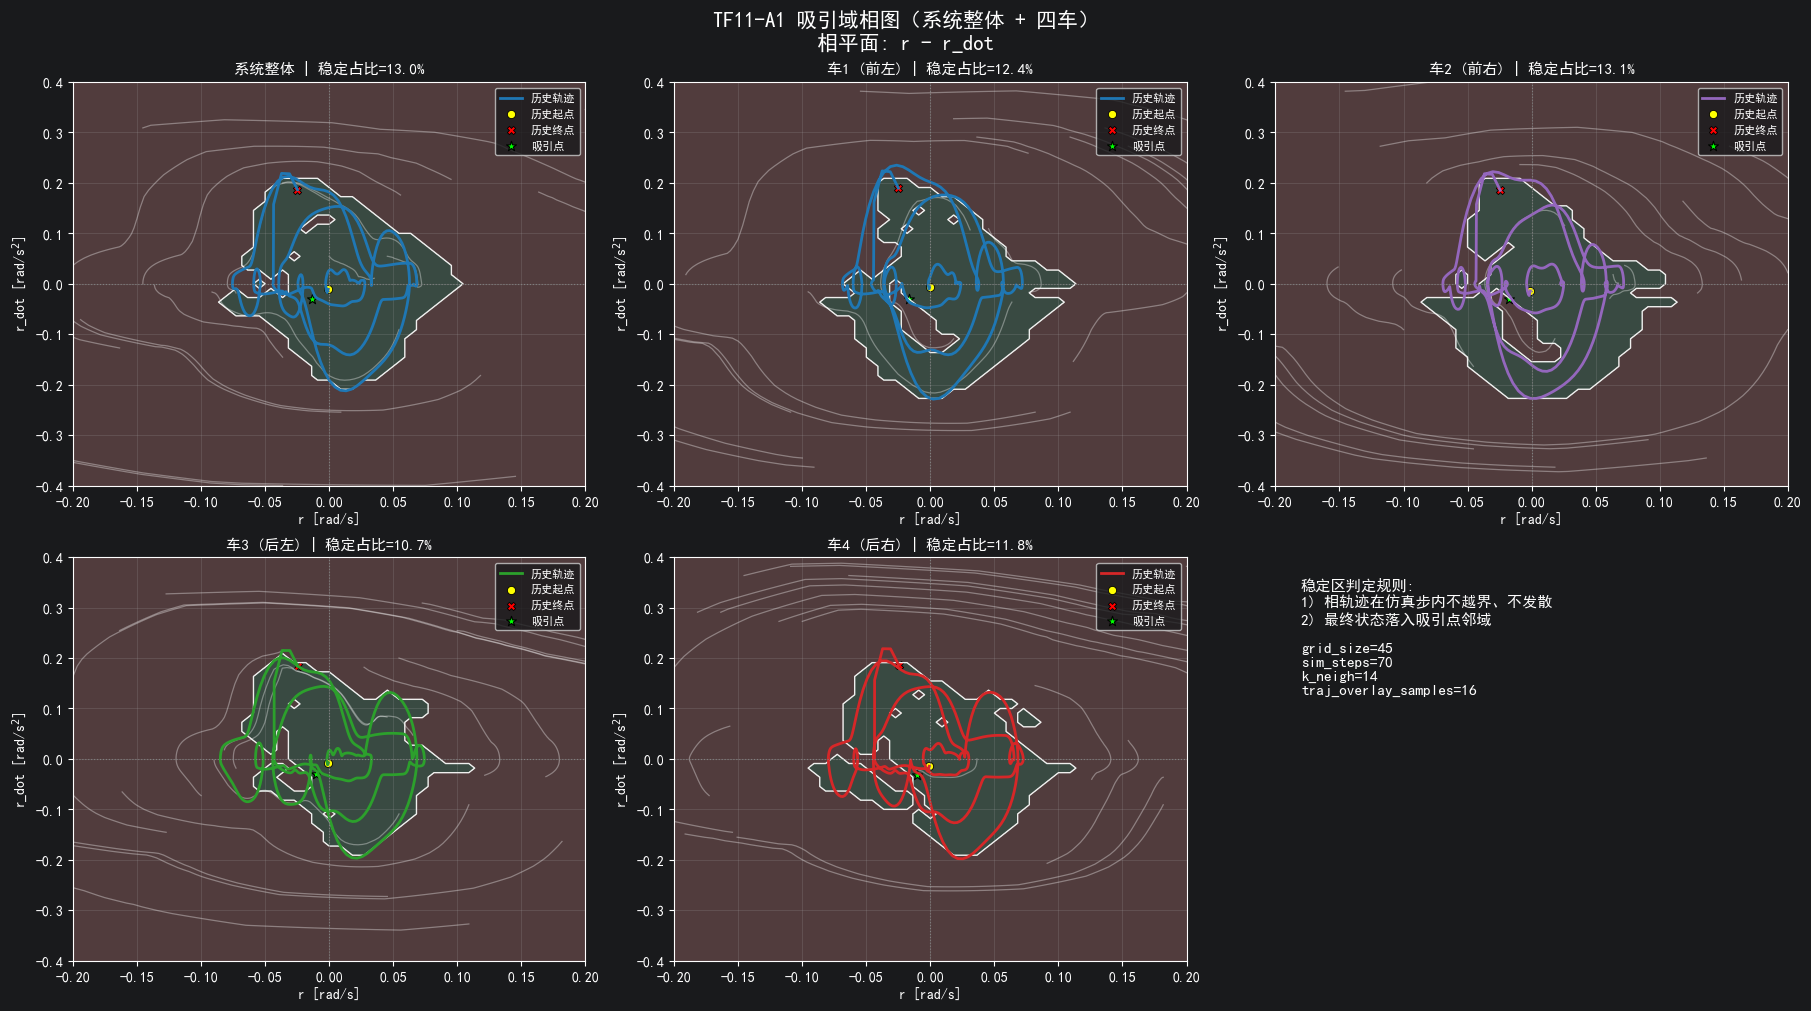

=== 相轨迹簇图 + 吸引域相图 生成完成 ===
系统整体: 样本点=1059, 稳定占比=13.0%
车1 (前左): 样本点=1059, 稳定占比=12.4%
车2 (前右): 样本点=1059, 稳定占比=13.1%
车3 (后左): 样本点=1059, 稳定占比=10.7%
车4 (后右): 样本点=1059, 稳定占比=11.8%


In [24]:

# =========================
# TF11-A1 相轨迹簇 + 吸引域相图（系统整体 + 四车）
# 相平面：r 与 r_dot
# =========================
from scipy.spatial import cKDTree

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

if 'main_result' not in globals() or main_result is None:
    raise RuntimeError('main_result 不存在，请先运行 TF11-A1 主方法单元。')
if 'team_state_hist' not in globals() or 'xt_actual_vehicles' not in globals():
    raise RuntimeError('team_state_hist / xt_actual_vehicles 缺失，请先运行结果回填单元。')
if 'dt' not in globals():
    raise RuntimeError('dt 不存在，请先运行基础配置单元。')

PHASE_BASIN_CFG = {
    # 吸引域底图
    'grid_size': 45,
    'sim_steps': 70,
    'k_neigh': 14,
    'dt_sim': float(dt),
    'r_bound_scale': 1.8,
    'rdot_bound_scale': 1.8,
    'attractor_tol_scale': 0.22,

    # 轨迹簇图（你要的“全是相轨迹”）
    'traj_only_samples': 120,
    'traj_only_len': 90,
    'traj_overlay_samples': 16,

    # 预处理
    'smooth_win': 7,
    'seed': 2026,
}


def _moving_average(arr, win):
    arr = np.asarray(arr, dtype=float).reshape(-1)
    if win <= 1 or arr.size < 3:
        return arr
    win = int(max(1, min(win, max(3, arr.size // 4))))
    if win % 2 == 0:
        win += 1
    ker = np.ones(win, dtype=float) / float(win)
    return np.convolve(arr, ker, mode='same')


def _phase_from_hist(r_hist, dt_val, smooth_win):
    r_hist = np.asarray(r_hist, dtype=float).reshape(-1)
    valid = np.isfinite(r_hist)
    r = r_hist[valid]
    if r.size < 8:
        return None
    r = _moving_average(r, smooth_win)
    rdot = np.gradient(r, float(dt_val))
    rdot = _moving_average(rdot, max(3, smooth_win - 2))
    rddot = np.gradient(rdot, float(dt_val))
    phase = np.column_stack([r, rdot])
    return phase, rddot


def _build_phase_model(phase_pts, rddot_targets):
    tree = cKDTree(phase_pts)
    y = np.asarray(rddot_targets, dtype=float).reshape(-1)

    def pred_rddot(x_query, k_neigh=12):
        xq = np.asarray(x_query, dtype=float)
        if xq.ndim == 1:
            xq = xq.reshape(1, 2)
        k_eff = int(max(1, min(k_neigh, phase_pts.shape[0])))
        d, idx = tree.query(xq, k=k_eff)
        if k_eff == 1:
            d = d.reshape(-1, 1)
            idx = idx.reshape(-1, 1)
        w = 1.0 / np.maximum(d, 1e-6)
        y_hat = np.sum(w * y[idx], axis=1) / np.sum(w, axis=1)
        return y_hat

    return pred_rddot


def _simulate_cloud(r0_grid, rd0_grid, pred_fn, cfg, attractor, r_lim, rd_lim):
    states = np.column_stack([r0_grid.reshape(-1), rd0_grid.reshape(-1)])
    alive = np.ones(states.shape[0], dtype=bool)

    for _ in range(int(cfg['sim_steps'])):
        if not np.any(alive):
            break
        s_alive = states[alive]
        rddot_hat = pred_fn(s_alive, k_neigh=cfg['k_neigh'])
        s_alive[:, 0] = s_alive[:, 0] + cfg['dt_sim'] * s_alive[:, 1]
        s_alive[:, 1] = s_alive[:, 1] + cfg['dt_sim'] * rddot_hat
        states[alive] = s_alive

        bad = (
            (~np.isfinite(states[:, 0])) | (~np.isfinite(states[:, 1])) |
            (np.abs(states[:, 0]) > r_lim) | (np.abs(states[:, 1]) > rd_lim)
        )
        alive = alive & (~bad)

    dist_final = np.sqrt((states[:, 0] - attractor[0]) ** 2 + (states[:, 1] - attractor[1]) ** 2)
    attract_tol = cfg['attractor_tol_scale'] * np.sqrt(r_lim ** 2 + rd_lim ** 2)
    stable = alive & (dist_final <= attract_tol)
    return stable.reshape(r0_grid.shape), states


def _simulate_traj(x0, pred_fn, cfg, r_lim, rd_lim, n_steps=60):
    x = np.asarray(x0, dtype=float).reshape(2)
    out = [x.copy()]
    for _ in range(int(n_steps)):
        if (not np.all(np.isfinite(x))) or (abs(x[0]) > r_lim) or (abs(x[1]) > rd_lim):
            break
        rdd = float(pred_fn(x, k_neigh=cfg['k_neigh'])[0])
        x = np.array([
            x[0] + cfg['dt_sim'] * x[1],
            x[1] + cfg['dt_sim'] * rdd,
        ], dtype=float)
        out.append(x.copy())
    return np.array(out, dtype=float)


sim_steps_phase = int(main_result.get('sim_steps', team_state_hist.shape[0] - 1))
sim_steps_phase = max(10, sim_steps_phase)

phase_items = []

# 系统整体
if isinstance(team_state_hist, np.ndarray) and team_state_hist.shape[1] >= 6:
    n_team = min(sim_steps_phase + 1, team_state_hist.shape[0])
    pack = _phase_from_hist(team_state_hist[:n_team, 5], dt, PHASE_BASIN_CFG['smooth_win'])
    if pack is not None:
        phase_pts, rddot_t = pack
        phase_items.append({
            'name': '系统整体',
            'color': 'tab:blue',
            'phase': phase_pts,
            'rddot': rddot_t,
        })

# 四车
labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
for v in range(num_vehicles):
    x_hist = np.asarray(xt_actual_vehicles[v], dtype=float)
    if x_hist.ndim != 2 or x_hist.shape[1] < 6:
        continue
    n_hist = min(sim_steps_phase + 1, x_hist.shape[0])
    pack = _phase_from_hist(x_hist[:n_hist, 5], dt, PHASE_BASIN_CFG['smooth_win'])
    if pack is None:
        continue
    phase_pts, rddot_t = pack
    phase_items.append({
        'name': labels_v[v] if v < len(labels_v) else f'车{v+1}',
        'color': colors_v[v % len(colors_v)],
        'phase': phase_pts,
        'rddot': rddot_t,
    })

if len(phase_items) == 0:
    raise RuntimeError('无可用相平面数据，无法绘制相轨迹/吸引域图。')

# 统一范围
r_all = np.concatenate([it['phase'][:, 0] for it in phase_items], axis=0)
rd_all = np.concatenate([it['phase'][:, 1] for it in phase_items], axis=0)
r_span = np.percentile(np.abs(r_all), 99)
rd_span = np.percentile(np.abs(rd_all), 99)
r_lim = max(0.20, float(PHASE_BASIN_CFG['r_bound_scale']) * float(r_span))
rd_lim = max(0.40, float(PHASE_BASIN_CFG['rdot_bound_scale']) * float(rd_span))

r_grid = np.linspace(-r_lim, r_lim, int(PHASE_BASIN_CFG['grid_size']))
rd_grid = np.linspace(-rd_lim, rd_lim, int(PHASE_BASIN_CFG['grid_size']))
RR, RRD = np.meshgrid(r_grid, rd_grid)

rng = np.random.default_rng(int(PHASE_BASIN_CFG['seed']))

# 先预计算每个对象的模型/稳定图
phase_models = []
for item in phase_items[:5]:
    phase_pts = item['phase']
    rddot_t = item['rddot']
    tail_n = max(8, int(0.12 * phase_pts.shape[0]))
    attractor = np.mean(phase_pts[-tail_n:, :], axis=0)
    pred_fn = _build_phase_model(phase_pts, rddot_t)
    stable_map, _ = _simulate_cloud(RR, RRD, pred_fn, PHASE_BASIN_CFG, attractor, r_lim, rd_lim)
    phase_models.append({
        **item,
        'pred_fn': pred_fn,
        'attractor': attractor,
        'stable_map': stable_map,
        'stable_ratio': float(np.mean(stable_map)),
    })

# =========================
# 图1：全是相轨迹（你要的风格）
# =========================
figA, axesA = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axesA = axesA.flatten()
figA.suptitle('TF11-A1 相轨迹簇图（系统整体 + 四车）\n相平面: r - r_dot', fontsize=15, fontweight='bold')

for idx, model in enumerate(phase_models):
    ax = axesA[idx]
    phase_pts = model['phase']
    pred_fn = model['pred_fn']

    # 大量初值轨迹
    n_traj = int(PHASE_BASIN_CFG['traj_only_samples'])
    seed_idx = rng.integers(0, RR.size, size=n_traj)
    starts = np.column_stack([RR.reshape(-1)[seed_idx], RRD.reshape(-1)[seed_idx]])
    cmap = plt.cm.turbo
    for j, s0 in enumerate(starts):
        tr = _simulate_traj(s0, pred_fn, PHASE_BASIN_CFG, r_lim, rd_lim, n_steps=PHASE_BASIN_CFG['traj_only_len'])
        if tr.shape[0] > 1:
            ax.plot(tr[:, 0], tr[:, 1], color=cmap(j / max(1, n_traj - 1)), alpha=0.72, linewidth=0.9)

    # 历史轨迹和关键点
    ax.plot(phase_pts[:, 0], phase_pts[:, 1], color='white', linewidth=2.0, alpha=0.95, label='历史轨迹')
    ax.scatter(phase_pts[0, 0], phase_pts[0, 1], s=34, c='yellow', edgecolors='k', linewidths=0.6, marker='o', label='历史起点')
    ax.scatter(phase_pts[-1, 0], phase_pts[-1, 1], s=34, c='red', edgecolors='k', linewidths=0.6, marker='X', label='历史终点')
    ax.scatter(model['attractor'][0], model['attractor'][1], s=56, c='lime', edgecolors='k', linewidths=0.8, marker='*', label='吸引点')

    ax.set_title(f"{model['name']} | 相轨迹簇", fontsize=11)
    ax.set_xlabel('r [rad/s]')
    ax.set_ylabel('r_dot [rad/s$^2$]')
    ax.set_xlim(-r_lim, r_lim)
    ax.set_ylim(-rd_lim, rd_lim)
    ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc='upper right')

if len(axesA) > 5:
    ax_info = axesA[5]
    ax_info.axis('off')
    txt = (
        '相轨迹簇图说明:\n'
        '1) 每条彩色线对应一个不同初值\n'
        '2) 白线为本次主实验历史相轨迹\n'
        '3) 黄/红/绿分别是起点/终点/吸引点\n\n'
        f"traj_only_samples={PHASE_BASIN_CFG['traj_only_samples']}\n"
        f"traj_only_len={PHASE_BASIN_CFG['traj_only_len']}"
    )
    ax_info.text(0.05, 0.95, txt, va='top', ha='left', fontsize=11)

plt.show()

# =========================
# 图2：吸引域稳定区 + 相轨迹
# =========================
figB, axesB = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axesB = axesB.flatten()
figB.suptitle('TF11-A1 吸引域相图（系统整体 + 四车）\n相平面: r - r_dot', fontsize=15, fontweight='bold')

for idx, model in enumerate(phase_models):
    ax = axesB[idx]
    phase_pts = model['phase']

    bg = np.where(model['stable_map'], 1.0, 0.0)
    ax.contourf(RR, RRD, bg, levels=[-0.1, 0.5, 1.1], alpha=0.26, colors=['#f59e9e', '#95d5b2'])
    ax.contour(RR, RRD, bg, levels=[0.5], colors='white', linewidths=1.0, alpha=0.9)

    # 少量轨迹叠加
    seed_idx = rng.integers(0, RR.size, size=int(PHASE_BASIN_CFG['traj_overlay_samples']))
    starts = np.column_stack([RR.reshape(-1)[seed_idx], RRD.reshape(-1)[seed_idx]])
    for s0 in starts:
        tr = _simulate_traj(s0, model['pred_fn'], PHASE_BASIN_CFG, r_lim, rd_lim, n_steps=PHASE_BASIN_CFG['traj_only_len'])
        if tr.shape[0] > 1:
            ax.plot(tr[:, 0], tr[:, 1], color='white', alpha=0.35, linewidth=0.9)

    ax.plot(phase_pts[:, 0], phase_pts[:, 1], color=model['color'], linewidth=2.0, label='历史轨迹')
    ax.scatter(phase_pts[0, 0], phase_pts[0, 1], s=35, c='yellow', edgecolors='k', linewidths=0.6, marker='o', label='历史起点')
    ax.scatter(phase_pts[-1, 0], phase_pts[-1, 1], s=35, c='red', edgecolors='k', linewidths=0.6, marker='X', label='历史终点')
    ax.scatter(model['attractor'][0], model['attractor'][1], s=56, c='lime', edgecolors='k', linewidths=0.8, marker='*', label='吸引点')

    ax.set_title(f"{model['name']} | 稳定占比={model['stable_ratio']*100:.1f}%", fontsize=11)
    ax.set_xlabel('r [rad/s]')
    ax.set_ylabel('r_dot [rad/s$^2$]')
    ax.set_xlim(-r_lim, r_lim)
    ax.set_ylim(-rd_lim, rd_lim)
    ax.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc='upper right')

if len(axesB) > 5:
    ax_info = axesB[5]
    ax_info.axis('off')
    txt = (
        '稳定区判定规则:\n'
        '1) 相轨迹在仿真步内不越界、不发散\n'
        '2) 最终状态落入吸引点邻域\n\n'
        f"grid_size={PHASE_BASIN_CFG['grid_size']}\n"
        f"sim_steps={PHASE_BASIN_CFG['sim_steps']}\n"
        f"k_neigh={PHASE_BASIN_CFG['k_neigh']}\n"
        f"traj_overlay_samples={PHASE_BASIN_CFG['traj_overlay_samples']}"
    )
    ax_info.text(0.05, 0.95, txt, va='top', ha='left', fontsize=11)

plt.show()

print('=== 相轨迹簇图 + 吸引域相图 生成完成 ===')
for model in phase_models:
    print(f"{model['name']}: 样本点={model['phase'].shape[0]}, 稳定占比={model['stable_ratio']*100:.1f}%")


=== Cargo force summary ===
{'fx_peak_abs': 1103.0328911872516, 'fy_peak_abs': 1305.5556299059244, 'mz_peak_abs': 1382.061183093021, 'corner_load_min': 4468.242607476324, 'corner_load_max': 5341.757392523676}
payload_change_mask = (0, 1, 2, 3)


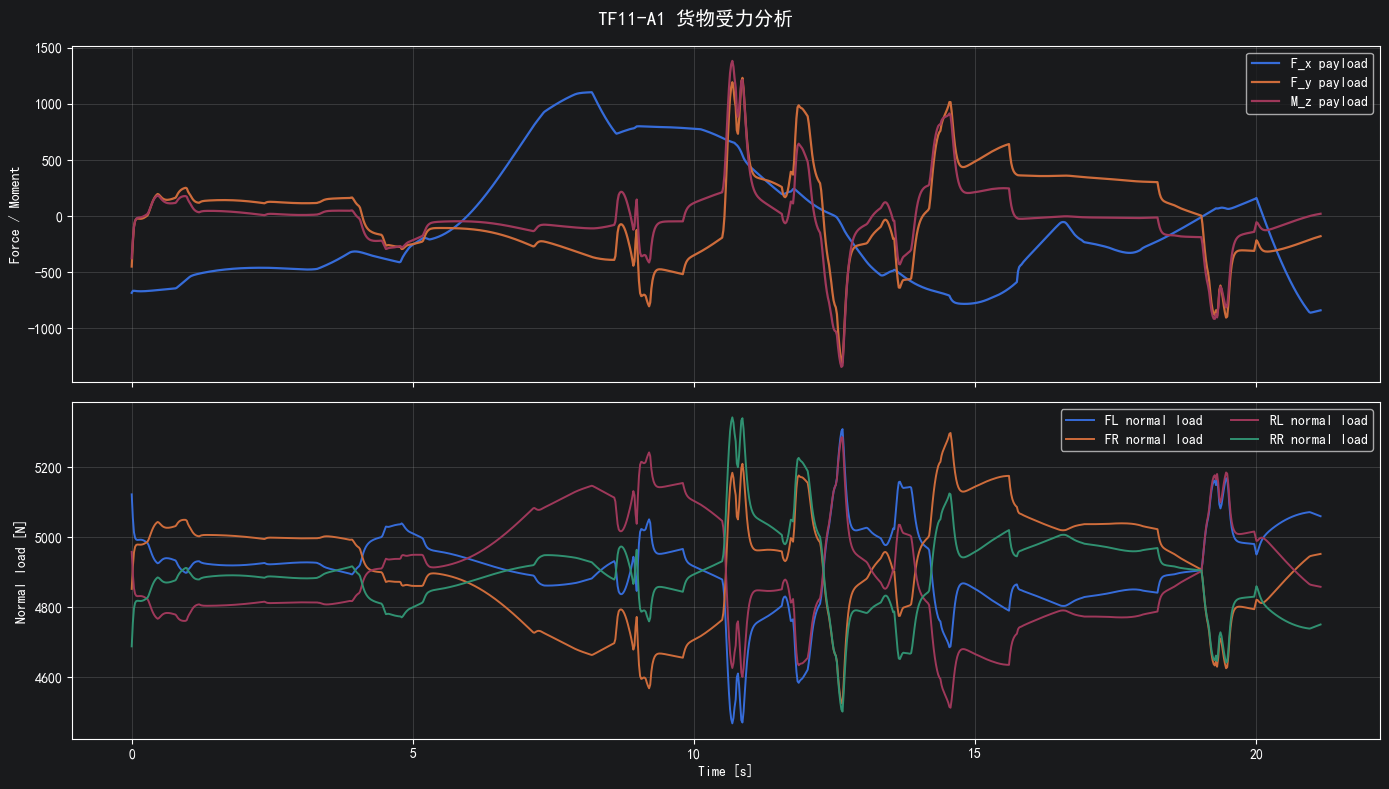

In [22]:
# =========================
# TF11-A1 cargo force analysis
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
if 'payload_force_hist' not in globals() or len(payload_force_hist) == 0:
    raise RuntimeError('payload_force_hist is empty. Run the TF11-A1 main cell first.')
force_steps = len(payload_force_hist)
t_force = np.arange(force_steps) * dt
fx_hist = np.array([item['fx_payload'] for item in payload_force_hist], dtype=float)
fy_hist = np.array([item['fy_payload'] for item in payload_force_hist], dtype=float)
mz_hist = np.array([item['mz_payload'] for item in payload_force_hist], dtype=float)
corner_load_hist = np.array([item['corner_normal_loads'] for item in payload_force_hist], dtype=float)
print('=== Cargo force summary ===')
print(payload_force_summary)
print('payload_change_mask =', payload_change_mask)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('TF11-A1 货物受力分析', fontsize=14, fontweight='bold')
axes[0].plot(t_force, fx_hist, label='F_x payload', linewidth=1.6)
axes[0].plot(t_force, fy_hist, label='F_y payload', linewidth=1.6)
axes[0].plot(t_force, mz_hist, label='M_z payload', linewidth=1.6)
axes[0].set_ylabel('Force / Moment')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')
for idx, lab in enumerate(['FL','FR','RL','RR']):
    axes[1].plot(t_force, corner_load_hist[:, idx], label=f'{lab} normal load', linewidth=1.4)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Normal load [N]')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()


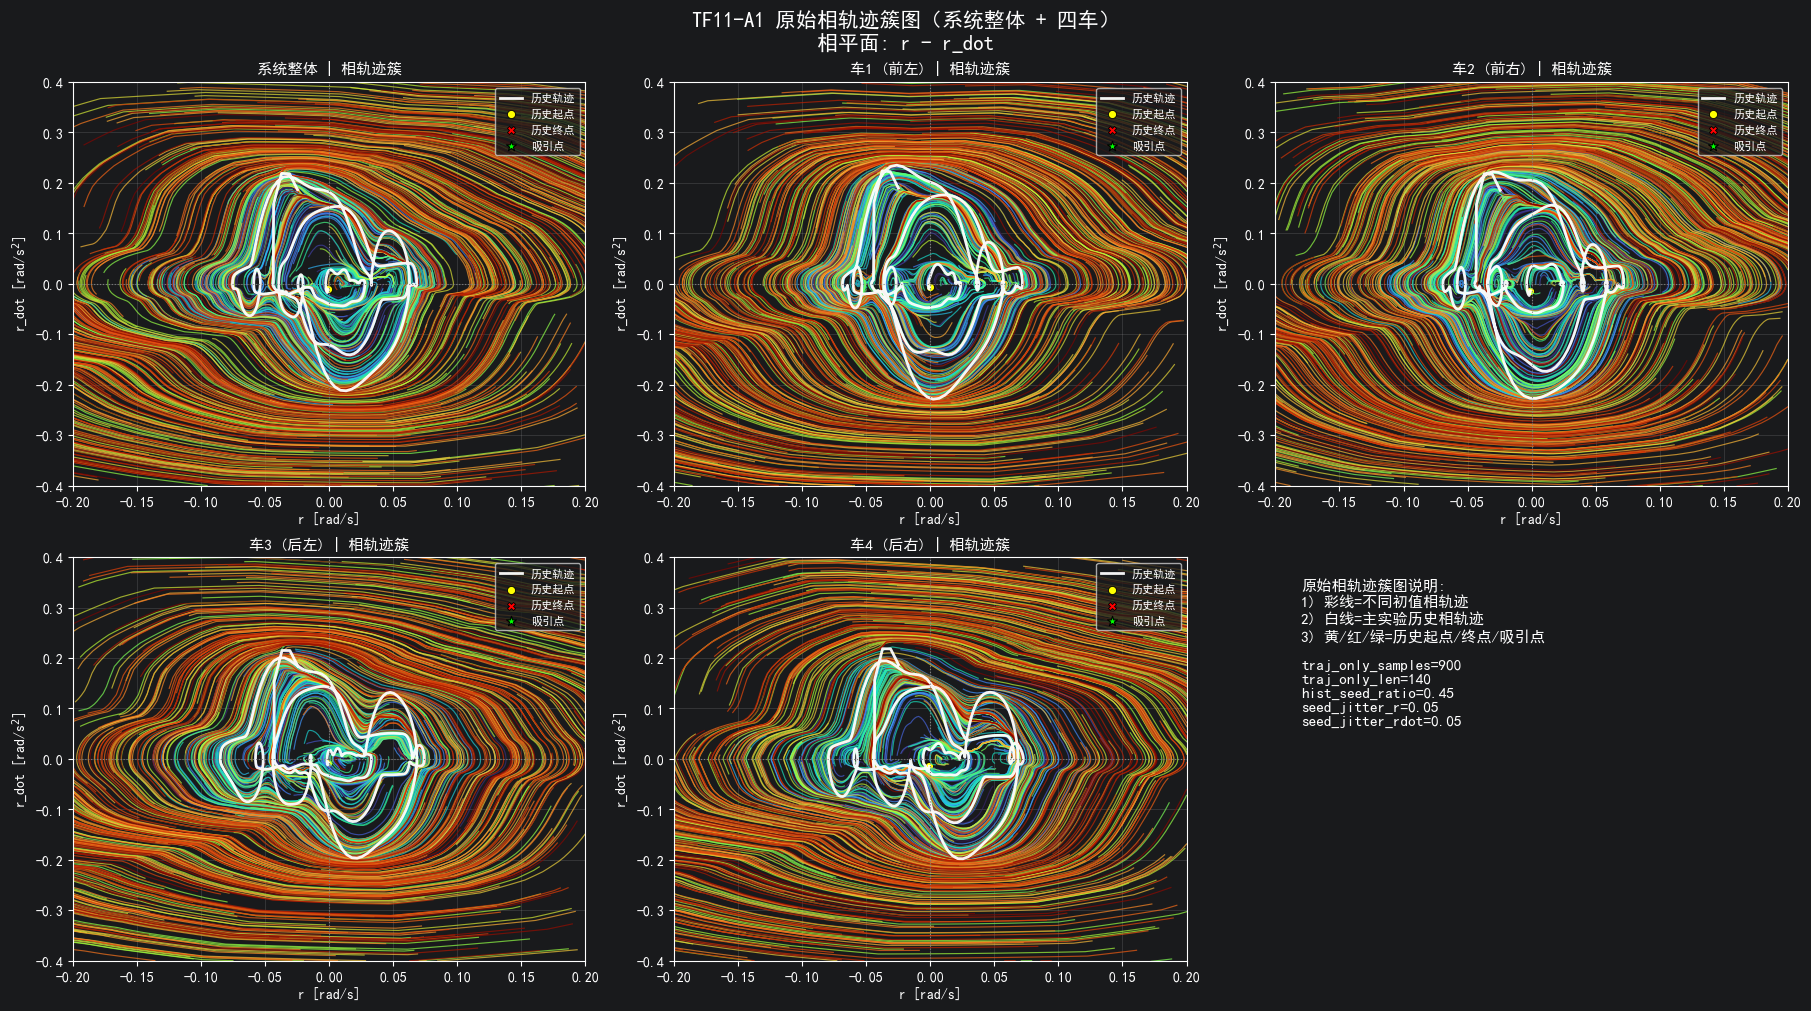

{'fig': <Figure size 1800x1000 with 6 Axes>,
 'cfg': {'k_neigh': 14,
  'dt_sim': 0.02,
  'r_bound_scale': 1.9,
  'rdot_bound_scale': 1.9,
  'smooth_win': 7,
  'seed': 2026,
  'traj_only_samples': 900,
  'traj_only_len': 140,
  'hist_seed_ratio': 0.45,
  'seed_jitter_r': 0.05,
  'seed_jitter_rdot': 0.05,
  'max_items': 5,
  'figsize': (18, 10)},
 'r_lim': 0.2,
 'rd_lim': 0.4,
 'items': [{'name': '系统整体',
   'phase_points': 1059,
   'seed_count': 900,
   'valid_traj_count': 900},
  {'name': '车1 (前左)',
   'phase_points': 1059,
   'seed_count': 900,
   'valid_traj_count': 900},
  {'name': '车2 (前右)',
   'phase_points': 1059,
   'seed_count': 900,
   'valid_traj_count': 900},
  {'name': '车3 (后左)',
   'phase_points': 1059,
   'seed_count': 900,
   'valid_traj_count': 900},
  {'name': '车4 (后右)',
   'phase_points': 1059,
   'seed_count': 900,
   'valid_traj_count': 900}]}

In [26]:
from tf11_a1_phase_cluster_raw import plot_raw_phase_clusters

raw_phase_summary = plot_raw_phase_clusters(
    main_result=main_result,
    team_state_hist=team_state_hist,
    xt_actual_vehicles=xt_actual_vehicles,
    dt=dt,
    num_vehicles=num_vehicles,
    cfg={
        "traj_only_samples": 900,  # 想更密可以继续加
        "traj_only_len": 140,
        "hist_seed_ratio": 0.45,
    },
    save_path="tf11_a1_raw_phase_clusters.png",
    show=True,
)

raw_phase_summary
